Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Loading data...
Data loaded. Total ingredients processed: 1154404

--- Processing Zipf's law ---
Zipf exponent (α): 1.8556


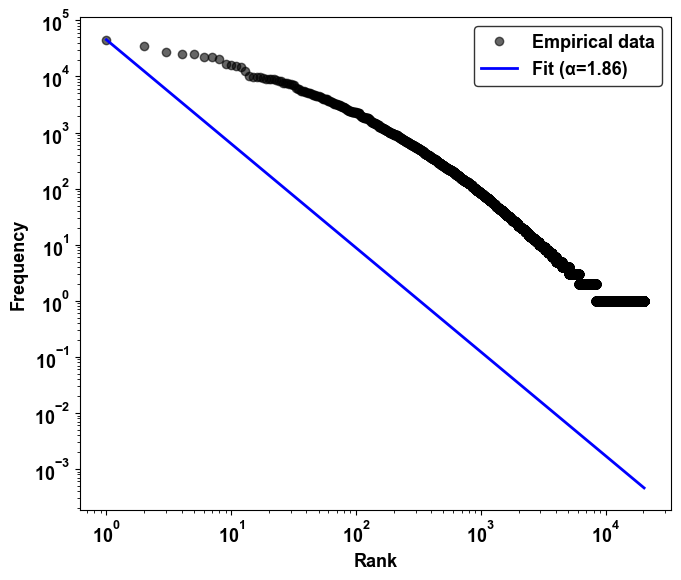


--- Processing Heaps' law ---
Heaps exponent (β): 0.5511


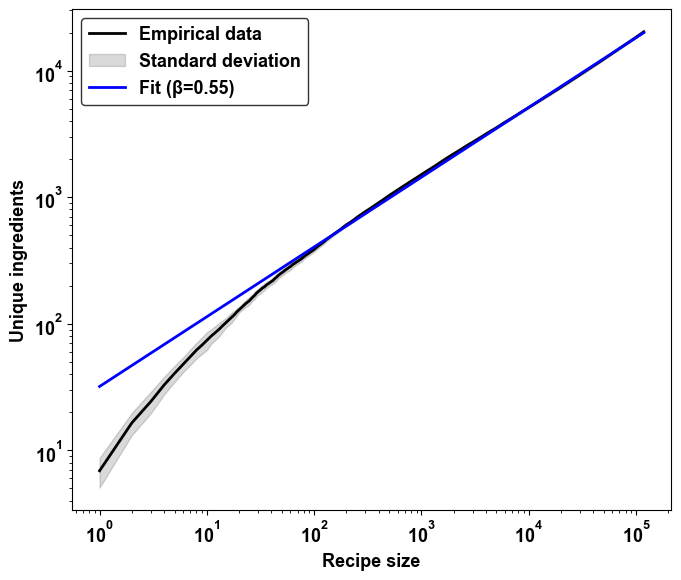


--- Processing Taylor's law ---
Taylor slope: 0.8004


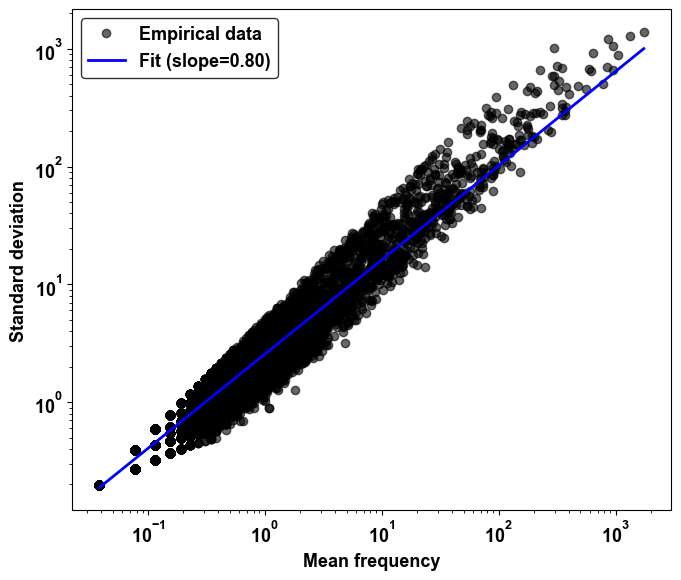

In [1]:
!pip install powerlaw
!pip install adjustText



import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


print("Loading data...")

df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

df_ing.rename(columns={'recipe_no': 'Recipe_id'}, inplace=True)

df_merged = pd.merge(df_ing, df_cuisine, on='Recipe_id', how='inner')

print(f"Data loaded. Total ingredients processed: {len(df_merged)}")


# =============================
# ZIPF LAW
# =============================

print("\n--- Processing Zipf's law ---")

ing_counts = df_merged['ing_id'].value_counts()
frequencies = ing_counts.values
ranks = np.arange(1, len(frequencies) + 1)

fit = powerlaw.Fit(frequencies, discrete=True, verbose=False)
alpha_dist = fit.alpha
alpha_zipf = 1.0 / (alpha_dist - 1.0)

print(f"Zipf exponent (α): {alpha_zipf:.4f}")

fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
ax.loglog(
    ranks,
    frequencies,
    marker='o',
    linestyle='none',
    alpha=0.6,
    color='black',
    label='Empirical data'
)

# Fit line
fit_line = frequencies[0] * (ranks ** -alpha_zipf)

ax.plot(
    ranks,
    fit_line,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (α={alpha_zipf:.2f})'
)

ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")

format_axes(ax)

plt.tight_layout()

plt.savefig("zipf_law_ingredient_frequency.png", dpi=300)
plt.savefig("zipf_law_ingredient_frequency.tif", dpi=300)

plt.show()


# =============================
# HEAPS LAW
# =============================

print("\n--- Processing Heaps' law ---")

recipe_groups = df_merged.groupby('Recipe_id')['ing_id'].apply(set).tolist()

num_simulations = 10
num_recipes = len(recipe_groups)

v_history = np.zeros((num_simulations, num_recipes))

for i in range(num_simulations):

    shuffled_recipes = np.random.permutation(recipe_groups)

    unique_ingredients = set()
    current_v = []

    for recipe_ingredients in shuffled_recipes:
        unique_ingredients.update(recipe_ingredients)
        current_v.append(len(unique_ingredients))

    v_history[i, :] = current_v

x_recipes = np.arange(1, num_recipes + 1)

y_mean = np.mean(v_history, axis=0)
y_std = np.std(v_history, axis=0)

burn_in = 0

x_fit = x_recipes[burn_in:]
y_fit_mean = y_mean[burn_in:]

beta, intercept = np.polyfit(np.log(x_fit), np.log(y_fit_mean), 1)
K_value = np.exp(intercept)

print(f"Heaps exponent (β): {beta:.4f}")

fig, ax = plt.subplots(figsize=(7,6))

# Empirical mean
ax.plot(
    x_recipes,
    y_mean,
    color='black',
    linewidth=2,
    label='Empirical data'
)

# Standard deviation band
ax.fill_between(
    x_recipes,
    y_mean - y_std,
    y_mean + y_std,
    color='black',
    alpha=0.15,
    label='Standard deviation'
)

# Fit
ax.plot(
    x_fit,
    K_value * (x_fit ** beta),
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (β={beta:.2f})'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Unique ingredients", fontweight="bold")

format_axes(ax)

plt.tight_layout()

plt.savefig("heaps_law_vocabulary_growth.png", dpi=300)
plt.savefig("heaps_law_vocabulary_growth.tif", dpi=300)

plt.show()


# =============================
# TAYLOR LAW
# =============================

print("\n--- Processing Taylor's law ---")

cuisine_counts = pd.crosstab(df_merged['ing_id'], df_merged['Cuisine'])

mu_vec = cuisine_counts.mean(axis=1)
sigma_vec = cuisine_counts.std(axis=1)

mask = (mu_vec > 0) & (sigma_vec > 0)

mu_vec = mu_vec[mask]
sigma_vec = sigma_vec[mask]

slope, intercept = np.polyfit(np.log(mu_vec), np.log(sigma_vec), 1)

print(f"Taylor slope: {slope:.4f}")

fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
ax.loglog(
    mu_vec,
    sigma_vec,
    marker='o',
    linestyle='none',
    alpha=0.6,
    color='black',
    label='Empirical data'
)

fit_x = np.linspace(min(mu_vec), max(mu_vec), 100)
fit_y = np.exp(intercept) * (fit_x ** slope)

# Fit line
ax.plot(
    fit_x,
    fit_y,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (slope={slope:.2f})'
)

ax.set_xlabel("Mean frequency", fontweight="bold")
ax.set_ylabel("Standard deviation", fontweight="bold")

format_axes(ax)

plt.tight_layout()

plt.savefig("taylors_law_fluctuation_scaling.png", dpi=300)
plt.savefig("taylors_law_fluctuation_scaling.tif", dpi=300)

plt.show()

Fitted parameters: a=13.0627, b=-0.2517, c=-0.0182


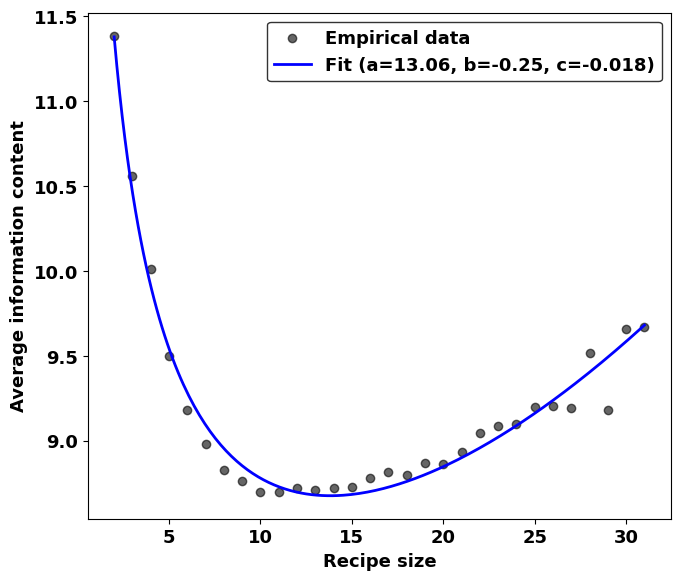

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ---- Load Data ----
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")

ing_counts = df_ing['ing_id'].value_counts()
total_occurrences = len(df_ing)

ing_probs = ing_counts / total_occurrences

df_ing['prob'] = df_ing['ing_id'].map(ing_probs)

df_ing['IC'] = -np.log2(df_ing['prob'])

recipe_stats = df_ing.groupby('recipe_no').agg(
    x=('ing_id', 'count'),
    y=('IC', 'mean')
)

ma_data = recipe_stats.groupby('x')['y'].mean().reset_index()

count_per_length = recipe_stats['x'].value_counts()
valid_lengths = count_per_length[count_per_length >= 10].index
ma_data = ma_data[ma_data['x'].isin(valid_lengths)].sort_values('x')

x_data = ma_data['x'].values
y_data = ma_data['y'].values


def menzerath_altmann(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)


try:
    p0 = [np.mean(y_data), -0.1, 0.0]

    popt, pcov = curve_fit(
        menzerath_altmann,
        x_data,
        y_data,
        p0=p0,
        maxfev=5000
    )

    A_fit, b_fit, c_fit = popt

    print(f"Fitted parameters: a={A_fit:.4f}, b={b_fit:.4f}, c={c_fit:.4f}")

    fit_success = True

except Exception as e:

    print(f"Fitting failed: {e}")
    fit_success = False


# ---- Plot ----
fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
ax.scatter(
    x_data,
    y_data,
    color='black',
    alpha=0.6,
    label='Empirical data'
)

if fit_success:

    x_line = np.linspace(x_data.min(), x_data.max(), 200)

    y_line = menzerath_altmann(x_line, *popt)

    ax.plot(
        x_line,
        y_line,
        color='blue',
        linewidth=2,
        label=f'Fit (a={A_fit:.2f}, b={b_fit:.2f}, c={c_fit:.3f})'
    )

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")

format_axes(ax)

plt.tight_layout()

plt.savefig("menzerath_altmann_recipe_structure.png", dpi=300)
plt.savefig("menzerath_altmann_recipe_structure.tif", dpi=300)

plt.show()

------------------------------
Corrected α (Head fit): 1.5283
------------------------------


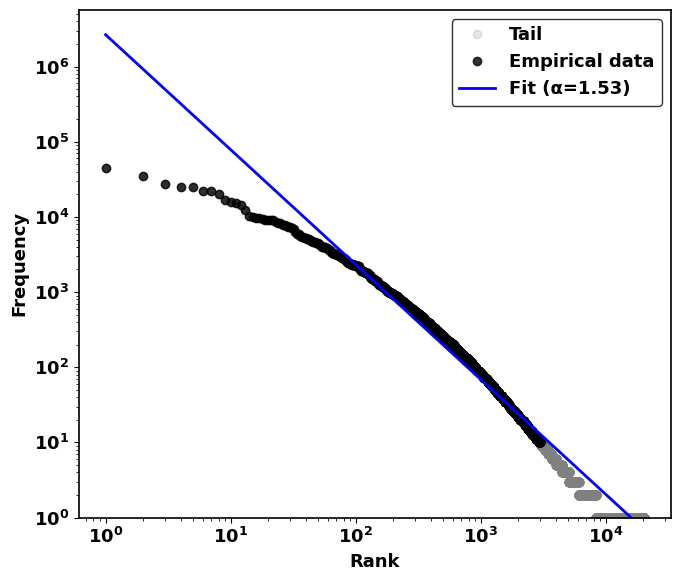

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False) # Rule 5: No grid

    # Rule 6: Plots must be boxed
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# Load Data
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")

# Prepare Data
ing_counts = df_ing['ing_id'].value_counts()

frequencies = ing_counts.values
ranks = np.arange(1, len(frequencies) + 1)

# Cutoff
cutoff_rank = 3000

ranks_fit = ranks[:cutoff_rank]
freqs_fit = frequencies[:cutoff_rank]

# Linear Regression on Log data
log_ranks = np.log(ranks_fit)
log_freqs = np.log(freqs_fit)

slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
# Changed variable to alpha to be mathematically consistent
alpha = -slope

print("-" * 30)
print(f"Corrected α (Head fit): {alpha:.4f}")
print("-" * 30)

# ==========================================
# Plot
# ==========================================

fig, ax = plt.subplots(figsize=(7,6))

# Tail
ax.loglog(
    ranks,
    frequencies,
    marker='o',
    linestyle='none',
    alpha=0.2,
    color='gray',
    label='Tail'
)

# Empirical data (head)
ax.loglog(
    ranks_fit,
    freqs_fit,
    marker='o',
    linestyle='none',
    alpha=0.8,
    color='black',
    markersize=6,
    label='Empirical data'
)

# Fit line
fit_x = np.linspace(1, len(ranks), 200)
fit_y = np.exp(intercept) * (fit_x ** -alpha)

ax.plot(
    fit_x,
    fit_y,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (α={alpha:.2f})'  # <--- Changed Beta to Alpha here
)

# Axis labels
ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")

# Log scale
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(bottom=1)

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("zipf_head_tail_best_fit.png", dpi=300)
plt.savefig("zipf_head_tail_best_fit.tif", dpi=300)

plt.show()

Total unique ingredients: 20280

--- Applying maximum likelihood estimation ---

Results from likelihood method:
  - Optimal cutoff (xmin): 3.0
  - Power law exponent (α): 1.5389
  - Standard error (sigma): 0.0069
  - Calculated rank-frequency slope (β): 1.8556

--- Performing hypothesis testing ---
Log-likelihood ratio (R): -4.9698
p-value: 0.0000
-> Evidence favors the lognormal distribution.


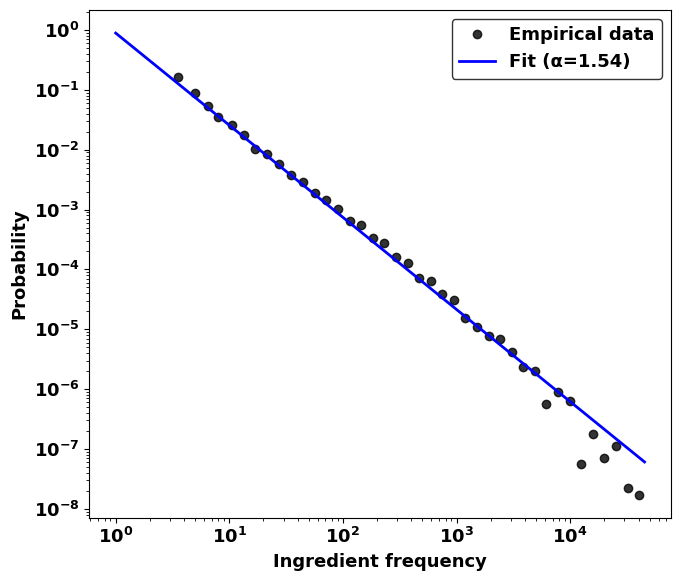

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. Load data
# ==========================================
df = pd.read_csv("RecipeID_Ing_ID.csv")

ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

print(f"Total unique ingredients: {len(data)}")

# ==========================================
# 2. Fit model (MLE)
# ==========================================
print("\n--- Applying maximum likelihood estimation ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)

xmin = fit.xmin
alpha = fit.alpha
sigma = fit.sigma

print("\nResults from likelihood method:")
print(f"  - Optimal cutoff (xmin): {xmin}")
print(f"  - Power law exponent (α): {alpha:.4f}")
print(f"  - Standard error (sigma): {sigma:.4f}")

beta = 1.0 / (alpha - 1.0)
print(f"  - Calculated rank-frequency slope (β): {beta:.4f}")

# ==========================================
# 3. Hypothesis testing
# ==========================================
print("\n--- Performing hypothesis testing ---")

R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)

print(f"Log-likelihood ratio (R): {R:.4f}")
print(f"p-value: {p:.4f}")

if R > 0:
    print("-> Evidence favors the power law distribution.")
else:
    print("-> Evidence favors the lognormal distribution.")

# ==========================================
# 4. Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
fit.plot_pdf(
    color='black',
    linestyle='none',
    marker='o',
    alpha=0.8,
    markersize=6,
    label='Empirical data',
    ax=ax
)

# Continuous fitted line
x_max = np.max(data)
x_line = np.arange(1, x_max + 1)

y_ref = fit.power_law.pdf(np.array([xmin]))[0]
y_line = y_ref * (x_line / xmin) ** -alpha

ax.plot(
    x_line,
    y_line,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=rf'Fit (α={alpha:.2f})'
)

ax.set_xlabel("Ingredient frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")

ax.set_xscale("log")
ax.set_yscale("log")

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("zipf_likelihood_method_fit.png", dpi=300)
plt.savefig("zipf_likelihood_method_fit.tif", dpi=300)

plt.show()

Loading data...

--- Processing Heaps' law (rigorous fit) ---
Running 10 simulations to generate stable growth curve...
------------------------------
Heaps law parameters (best fit):
  Constant (K): 27.2029
  Exponent (β): 0.5659
------------------------------
Model comparison (AIC):
  Heaps law: 1009254.14
  Linear model: 1572764.39
Result: Evidence favors Heaps law.
------------------------------


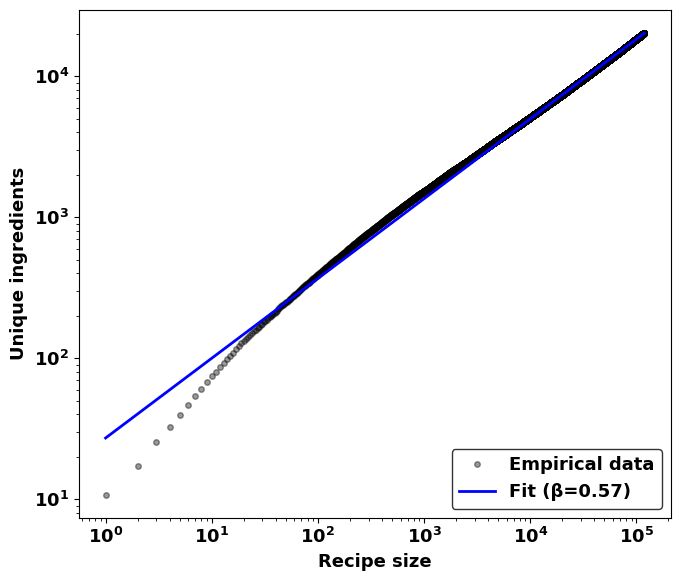

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    # Added loc='lower right' here to move the legend
    legend = ax.legend(frameon=True, loc='lower right')
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. Load data
# ==========================================
print("Loading data...")
df = pd.read_csv("RecipeID_Ing_ID.csv")

# ==========================================
# 2. Simulate vocabulary growth
# ==========================================
print("\n--- Processing Heaps' law (rigorous fit) ---")

recipe_groups = df.groupby('recipe_no')['ing_id'].apply(set).tolist()
n_recipes = len(recipe_groups)

num_simulations = 10
v_history = np.zeros((num_simulations, n_recipes))

print(f"Running {num_simulations} simulations to generate stable growth curve...")

for i in range(num_simulations):

    shuffled = np.random.permutation(np.array(recipe_groups, dtype=object))

    unique_set = set()
    current_v = []

    for r in shuffled:
        unique_set.update(r)
        current_v.append(len(unique_set))

    v_history[i, :] = current_v


# Mean curve
y_mean = np.mean(v_history, axis=0)
x_data = np.arange(1, n_recipes + 1)


# ==========================================
# 3. Define models
# ==========================================
def heaps_model(x, K, beta):
    return K * (x ** beta)

def linear_model(x, m, c):
    return m * x + c


# ==========================================
# 4. Fit models
# ==========================================
burn_in = 0

x_fit = x_data[burn_in:]
y_fit = y_mean[burn_in:]

popt_heaps, _ = curve_fit(heaps_model, x_fit, y_fit, p0=[10, 0.5])
popt_lin, _ = curve_fit(linear_model, x_fit, y_fit, p0=[1, 0])


# ==========================================
# 5. Model comparison (AIC)
# ==========================================
def calculate_aic(y_true, y_pred, num_params):
    rss = np.sum((y_true - y_pred) ** 2)
    n = len(y_true)
    return n * np.log(rss / n) + 2 * num_params


y_pred_heaps = heaps_model(x_fit, *popt_heaps)
aic_heaps = calculate_aic(y_fit, y_pred_heaps, num_params=2)

y_pred_lin = linear_model(x_fit, *popt_lin)
aic_lin = calculate_aic(y_fit, y_pred_lin, num_params=2)

print("-" * 30)
print("Heaps law parameters (best fit):")
print(f"  Constant (K): {popt_heaps[0]:.4f}")
print(f"  Exponent (β): {popt_heaps[1]:.4f}")
print("-" * 30)

print("Model comparison (AIC):")
print(f"  Heaps law: {aic_heaps:.2f}")
print(f"  Linear model: {aic_lin:.2f}")

if aic_heaps < aic_lin:
    print("Result: Evidence favors Heaps law.")
else:
    print("Result: Evidence favors linear growth.")
print("-" * 30)


# ==========================================
# 6. Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
ax.plot(
    x_data,
    y_mean,
    marker='o',
    linestyle='none',
    color='black',
    markersize=4,
    alpha=0.4,
    label='Empirical data'
)

# Heaps fit
ax.plot(
    x_fit,
    y_pred_heaps,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (β={popt_heaps[1]:.2f})'
)

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Unique ingredients", fontweight="bold")

ax.set_xscale('log')
ax.set_yscale('log')

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("heaps_law_rigorous_fit.png", dpi=300)
plt.savefig("heaps_law_rigorous_fit.tif", dpi=300)

plt.show()


--- Processing Menzerath-Altmann (Likelihood method) ---
------------------------------
Maximum likelihood estimation results:
  Full MA model LL: 71.9325
  Power law model LL: 20.7691
------------------------------
Likelihood ratio test:
  Statistic D: 102.3267
  p value: 0.000000
Result: Evidence favors full Menzerath-Altmann law.
------------------------------


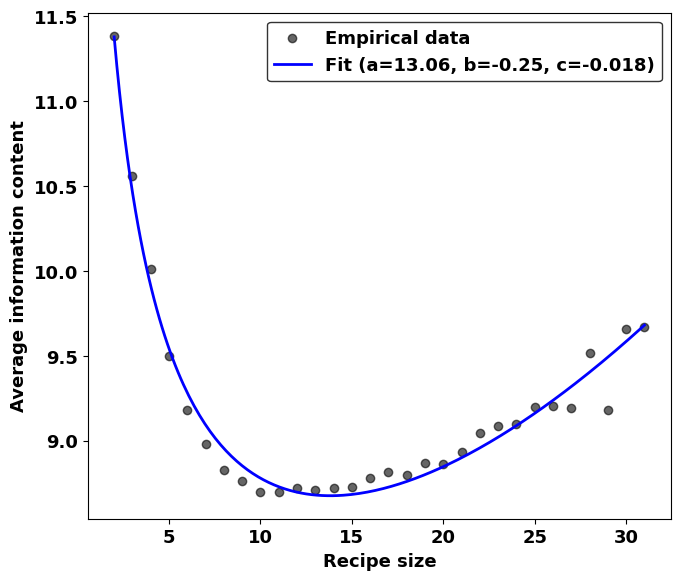

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# Load data
# ==========================================
df = pd.read_csv("RecipeID_Ing_ID.csv")

print("\n--- Processing Menzerath-Altmann (Likelihood method) ---")

# Calculate information content
ing_counts = df['ing_id'].value_counts()
probs = ing_counts / len(df)

df['ic'] = -np.log2(df['ing_id'].map(probs))

# Group by recipe
groups = df.groupby('recipe_no')

recipe_lengths = groups.size()
recipe_mean_ic = groups['ic'].mean()

# Mean-field averaging
ma_data = pd.DataFrame({
    'Length': recipe_lengths,
    'Mean_IC': recipe_mean_ic
})

ma_grouped = ma_data.groupby('Length')['Mean_IC'].mean().reset_index()

# Stability filtering
valid_counts = ma_data['Length'].value_counts()
valid_lengths = valid_counts[valid_counts >= 10].index

ma_grouped = ma_grouped[
    ma_grouped['Length'].isin(valid_lengths)
].sort_values('Length')

x_data = ma_grouped['Length'].values
y_data = ma_grouped['Mean_IC'].values

n_samples = len(y_data)


# ==========================================
# Models
# ==========================================
def ma_model(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)

def power_model(x, A, b):
    return A * (x ** b)


# ==========================================
# Fitting
# ==========================================
try:
    popt_ma, _ = curve_fit(
        ma_model,
        x_data,
        y_data,
        p0=[10, -0.1, 0.01],
        maxfev=10000
    )

    y_pred_ma = ma_model(x_data, *popt_ma)
    rss_ma = np.sum((y_data - y_pred_ma) ** 2)

    fit_success = True

except:
    fit_success = False


try:
    popt_pow, _ = curve_fit(
        power_model,
        x_data,
        y_data,
        p0=[10, -0.1],
        maxfev=10000
    )

    y_pred_pow = power_model(x_data, *popt_pow)
    rss_pow = np.sum((y_data - y_pred_pow) ** 2)

except:
    fit_success = False


# ==========================================
# Likelihood test
# ==========================================
if fit_success:

    ll_ma = -0.5 * n_samples * np.log(rss_ma / n_samples)
    ll_pow = -0.5 * n_samples * np.log(rss_pow / n_samples)

    D = -2 * (ll_pow - ll_ma)

    p_value = chi2.sf(D, df=1)

    print("-" * 30)
    print("Maximum likelihood estimation results:")
    print(f"  Full MA model LL: {ll_ma:.4f}")
    print(f"  Power law model LL: {ll_pow:.4f}")
    print("-" * 30)

    print("Likelihood ratio test:")
    print(f"  Statistic D: {D:.4f}")
    print(f"  p value: {p_value:.6f}")

    if p_value < 0.05:

        print("Result: Evidence favors full Menzerath-Altmann law.")

        best_model_label = f'Fit (a={popt_ma[0]:.2f}, b={popt_ma[1]:.2f}, c={popt_ma[2]:.3f})'
        model_func = ma_model
        model_params = popt_ma

    else:

        print("Result: Evidence favors simple power law.")

        best_model_label = f'Fit (a={popt_pow[0]:.2f}, b={popt_pow[1]:.2f})'
        model_func = power_model
        model_params = popt_pow

    print("-" * 30)

    # ==========================================
    # Plot
    # ==========================================
    fig, ax = plt.subplots(figsize=(7,6))

    # Empirical data
    ax.scatter(
        x_data,
        y_data,
        color='black',
        alpha=0.6,
        label='Empirical data'
    )

    # Fit
    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    y_line = model_func(x_line, *model_params)

    ax.plot(
        x_line,
        y_line,
        color='blue',
        linewidth=2,
        label=best_model_label
    )

    ax.set_xlabel("Recipe size", fontweight="bold")
    ax.set_ylabel("Average information content", fontweight="bold")

    format_axes(ax)

    plt.tight_layout()

    plt.savefig("menzerath_altmann_likelihood_test.png", dpi=300)
    plt.savefig("menzerath_altmann_likelihood_test.tif", dpi=300)

    plt.show()

else:
    print("Optimization failed.")

In [ ]:
!pip install powerlaw

import pandas as pd
import numpy as np
import powerlaw

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")
df = pd.read_csv("RecipeID_Ing_ID.csv")

# Get Frequency Data
ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

# ==========================================
# 2. CALCULATE ALPHA & CONFIDENCE
# ==========================================
print("\n--- Calculates Zipf's Law Parameters ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)

alpha = fit.alpha
sigma = fit.sigma
xmin = fit.xmin

# 95% Confidence Interval
ci_lower = alpha - (1.96 * sigma)
ci_upper = alpha + (1.96 * sigma)

# Rank-frequency slope
beta = 1.0 / (alpha - 1.0)

# ==========================================
# 3. PRINT RESULTS
# ==========================================
print("-" * 40)
print(f"RESULTS FOR LIKELIHOOD FIT (xmin={xmin})")
print("-" * 40)
print(f"Alpha (Distribution Exponent):  {alpha:.6f}")
print(f"Standard Error (Sigma):         {sigma:.6f}")
print(f"95% Confidence Interval:        [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"Beta (Zipf Rank Slope):         {beta:.6f}")
print("-" * 40)

# ==========================================
# 4. EXPORT RESULTS TO CSV
# ==========================================
results = pd.DataFrame({
    "xmin": [xmin],
    "alpha": [alpha],
    "sigma": [sigma],
    "ci_lower": [ci_lower],
    "ci_upper": [ci_upper],
    "beta": [beta]
})

results.to_csv("zipf_law_parameters.csv", index=False)

print("Results exported to zipf_law_parameters.csv")

Loading data...

--- Calculates Zipf's Law Parameters ---
----------------------------------------
RESULTS FOR LIKELIHOOD FIT (xmin=3.0)
----------------------------------------
Alpha (Distribution Exponent):  1.538921
Standard Error (Sigma):         0.006907
95% Confidence Interval:        [1.525383, 1.552459]
Beta (Zipf Rank Slope):         1.855560
----------------------------------------
Results exported to zipf_law_parameters.csv


Loading data...

--- Fitting distributions ---
Optimal cutoff (xmin): 3.0

--- Model comparison ---
Power law vs Lognormal: R=-4.9698, p=0.0000
Power law vs Exponential: R=22.3691, p=0.0000
Results exported to distribution_model_comparison.csv


/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


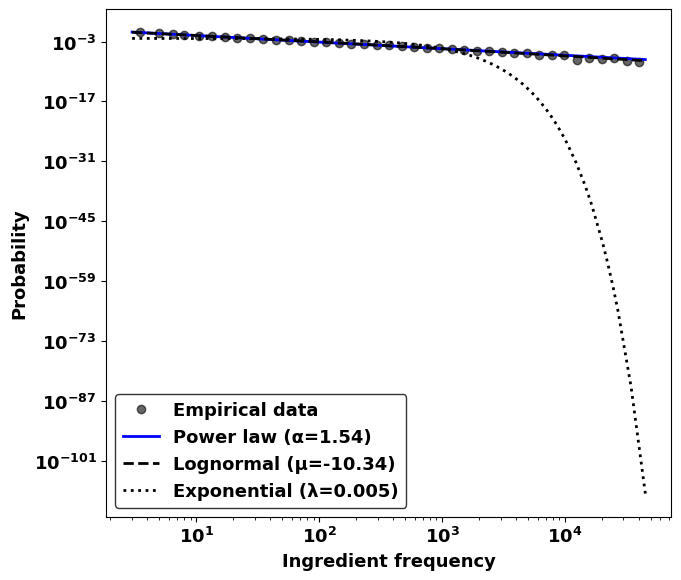

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. Load data
# ==========================================
print("Loading data...")
df = pd.read_csv("RecipeID_Ing_ID.csv")

ing_counts = df['ing_id'].value_counts()
data = ing_counts.values


# ==========================================
# 2. Fit models (MLE)
# ==========================================
print("\n--- Fitting distributions ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)
xmin = fit.xmin

print(f"Optimal cutoff (xmin): {xmin}")

# Power law
alpha = fit.power_law.alpha
sigma = fit.power_law.sigma

# Lognormal
mu = fit.lognormal.mu
sigma_log = fit.lognormal.sigma

# Exponential
lamb = fit.exponential.parameter1


# ==========================================
# 3. Model comparison
# ==========================================
print("\n--- Model comparison ---")

R_pl_ln, p_pl_ln = fit.distribution_compare(
    'power_law', 'lognormal', normalized_ratio=True)

R_pl_ex, p_pl_ex = fit.distribution_compare(
    'power_law', 'exponential', normalized_ratio=True)

winner_ln = "Power law" if R_pl_ln > 0 else "Lognormal"
winner_ex = "Power law" if R_pl_ex > 0 else "Exponential"

print(f"Power law vs Lognormal: R={R_pl_ln:.4f}, p={p_pl_ln:.4f}")
print(f"Power law vs Exponential: R={R_pl_ex:.4f}, p={p_pl_ex:.4f}")


# ==========================================
# 4. Export results to CSV
# ==========================================
results = pd.DataFrame({
    "xmin":[xmin],
    "alpha":[alpha],
    "sigma_alpha":[sigma],
    "lognormal_mu":[mu],
    "lognormal_sigma":[sigma_log],
    "exponential_lambda":[lamb],
    "R_powerlaw_lognormal":[R_pl_ln],
    "p_powerlaw_lognormal":[p_pl_ln],
    "R_powerlaw_exponential":[R_pl_ex],
    "p_powerlaw_exponential":[p_pl_ex],
    "winner_vs_lognormal":[winner_ln],
    "winner_vs_exponential":[winner_ex]
})

results.to_csv("distribution_model_comparison.csv", index=False)

print("Results exported to distribution_model_comparison.csv")


# ==========================================
# 5. Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
fit.plot_pdf(
    color='black',
    linestyle='none',
    marker='o',
    alpha=0.6,
    markersize=6,
    label='Empirical data',
    ax=ax
)

# Power law (main fit)
fit.power_law.plot_pdf(
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Power law (α={alpha:.2f})',
    ax=ax
)

# Lognormal
fit.lognormal.plot_pdf(
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Lognormal (μ={mu:.2f})',
    ax=ax
)

# Exponential
fit.exponential.plot_pdf(
    color='black',
    linestyle=':',
    linewidth=2,
    label=f'Exponential (λ={lamb:.3f})',
    ax=ax
)

ax.set_xlabel("Ingredient frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")

ax.set_xscale("log")
ax.set_yscale("log")

format_axes(ax)

plt.tight_layout()

plt.savefig("distribution_comparison_models.png", dpi=300)
plt.savefig("distribution_comparison_models.tif", dpi=300)

plt.show()

Analyzing 26 cuisines...


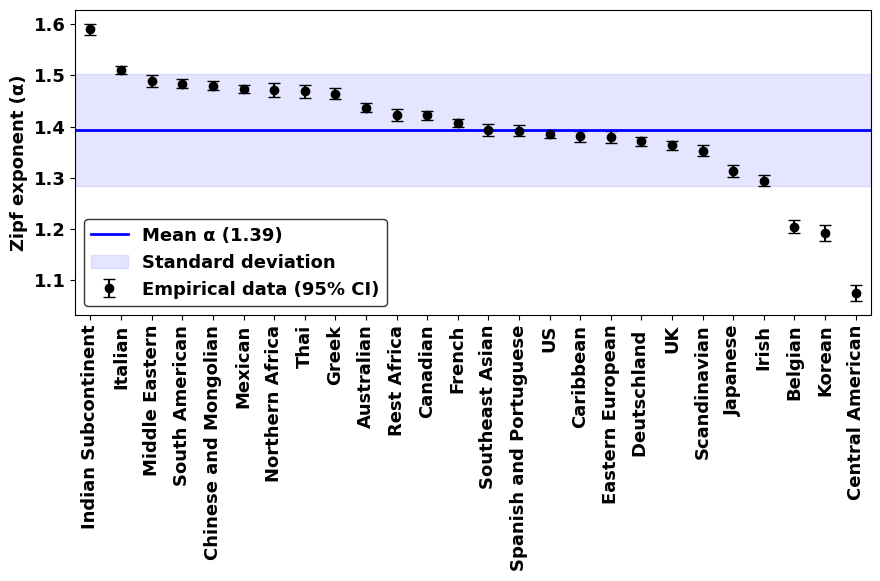

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# Load data
# ==========================================
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine]

    counts = subset['ing_id'].value_counts()

    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)

    if np.sum(mask) > 5:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            'Cuisine': cuisine,
            'Alpha': alpha,
            'Alpha_Low': alpha - alpha_ci_95,
            'Alpha_High': alpha + alpha_ci_95,
            'R_Squared': r_value**2
        })


df_results = pd.DataFrame(results).sort_values('Alpha', ascending=False)

# ==========================================
# Plot
# ==========================================
fig, ax = plt.subplots(figsize=(9,6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results['Alpha'] - df_results['Alpha_Low'],
    df_results['Alpha_High'] - df_results['Alpha']
]

# Empirical points
ax.errorbar(
    x_positions,
    df_results['Alpha'],
    yerr=y_errs,
    fmt='o',
    capsize=4,
    color='black',
    label='Empirical data (95% CI)'
)

# Mean alpha
mean_alpha = df_results['Alpha'].mean()
std_alpha = df_results['Alpha'].std()

# Mean line
ax.axhline(
    mean_alpha,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean α ({mean_alpha:.2f})'
)

# ---- FULL WIDTH STANDARD DEVIATION BAND ----
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))

lower_band = np.repeat(mean_alpha - std_alpha, len(x_band))
upper_band = np.repeat(mean_alpha + std_alpha, len(x_band))

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='Standard deviation'
)

# Axis labels
ax.set_ylabel("Zipf exponent (α)", fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)

# Remove margins so band touches edges
ax.margins(x=0)

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("zipf_alpha_by_cuisine.png", dpi=300)
plt.savefig("zipf_alpha_by_cuisine.tif", dpi=300)

plt.show()

Analyzing 26 cuisines...


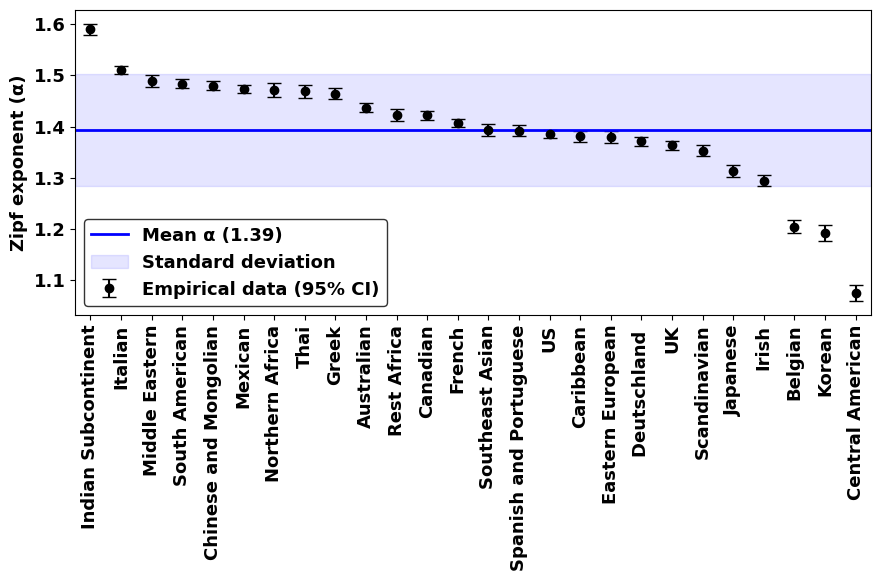

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')


# ==========================================
# 2. CALCULATE ZIPF α PER CUISINE
# ==========================================
cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine]

    counts = subset['ing_id'].value_counts()
    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)

    if np.sum(mask) > 5:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            'Cuisine': cuisine,
            'Alpha': alpha,
            'Alpha_Low': alpha - alpha_ci_95,
            'Alpha_High': alpha + alpha_ci_95,
            'R_Squared': r_value**2
        })

df_results = pd.DataFrame(results).sort_values('Alpha', ascending=False)


# ==========================================
# 3. GENERATE PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(9,6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results['Alpha'] - df_results['Alpha_Low'],
    df_results['Alpha_High'] - df_results['Alpha']
]

# Empirical data
ax.errorbar(
    x_positions,
    df_results['Alpha'],
    yerr=y_errs,
    fmt='o',
    capsize=5,
    color='black',
    label='Empirical data (95% CI)'
)

# Mean α
mean_alpha = df_results['Alpha'].mean()
std_alpha = df_results['Alpha'].std()

# Mean line
ax.axhline(
    mean_alpha,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean α ({mean_alpha:.2f})'
)

# Full width standard deviation band
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))

lower_band = np.repeat(mean_alpha - std_alpha, len(x_band))
upper_band = np.repeat(mean_alpha + std_alpha, len(x_band))

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='Standard deviation'
)

# Labels
ax.set_ylabel("Zipf exponent (α)", fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)

# Remove margins so band touches edges
ax.margins(x=0)

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("cuisine_zipf_alpha_universality.png", dpi=300)
plt.savefig("cuisine_zipf_alpha_universality.tif", dpi=300)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
print("Loading data...")
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

# Merge Ingredient data with Cuisine data
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ==========================================
# 2. CALCULATE ZIPF α PER CUISINE
# ==========================================
cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Calculating Zipf α for {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine]

    counts = subset['ing_id'].value_counts()
    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)

    if np.sum(mask) > 5:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            'Cuisine': cuisine,
            'Alpha': round(alpha, 4),
            'Lower_CI_95': round(alpha - alpha_ci_95, 4),
            'Upper_CI_95': round(alpha + alpha_ci_95, 4),
            'R_Squared': round(r_value**2, 4)
        })

# ==========================================
# 3. CREATE RESULTS TABLE
# ==========================================
df_results = pd.DataFrame(results)

# Sort by Alpha
df_results = df_results.sort_values('Alpha', ascending=False)

print("\n=== Zipf's Law α by Cuisine ===")
print(df_results.to_string(index=False))

# ==========================================
# 4. EXPORT TO CSV
# ==========================================
df_results.to_csv("zipf_alphas_by_cuisine.csv", index=False)

print("\nResults exported to: zipf_alphas_by_cuisine.csv")

Loading data...
Calculating Zipf α for 26 cuisines...

=== Zipf's Law α by Cuisine ===
               Cuisine  Alpha  Lower_CI_95  Upper_CI_95  R_Squared
   Indian Subcontinent 1.5896       1.5788       1.6005     0.9688
               Italian 1.5099       1.5019       1.5180     0.9625
        Middle Eastern 1.4893       1.4779       1.5007     0.9704
        South American 1.4838       1.4750       1.4925     0.9692
 Chinese and Mongolian 1.4801       1.4708       1.4893     0.9712
               Mexican 1.4738       1.4655       1.4820     0.9607
       Northern Africa 1.4708       1.4573       1.4843     0.9743
                  Thai 1.4686       1.4561       1.4811     0.9664
                 Greek 1.4644       1.4531       1.4758     0.9676
            Australian 1.4370       1.4281       1.4460     0.9700
           Rest Africa 1.4227       1.4110       1.4345     0.9675
              Canadian 1.4216       1.4137       1.4295     0.9732
                French 1.4071       1.3986

Calculating Heaps β for 26 cuisines...


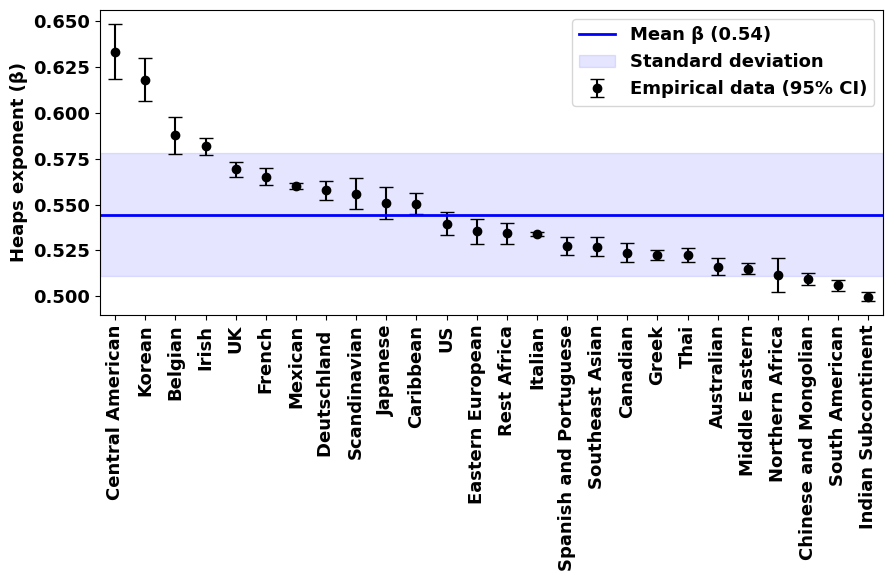

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# Load Data
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# Get Cuisines
cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Calculating Heaps β for {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    recipes = subset.groupby('recipe_no')['ing_id'].apply(set).tolist()

    np.random.seed(42)
    shuffled_recipes = np.random.permutation(np.array(recipes, dtype=object))

    unique_ingredients = set()
    x_n = []
    y_v = []
    total_tokens = 0

    sample_rate = 10 if len(shuffled_recipes) < 1000 else 50

    for i, recipe in enumerate(shuffled_recipes):
        unique_ingredients.update(recipe)
        total_tokens += len(recipe)

        if (i + 1) % sample_rate == 0:
            x_n.append(total_tokens)
            y_v.append(len(unique_ingredients))

    if len(x_n) > 5:
        log_n = np.log(np.array(x_n))
        log_v = np.log(np.array(y_v))

        slope, intercept, _, _, std_err = linregress(log_n, log_v)

        results.append({
            'Cuisine': cuisine,
            'Beta': slope,
            'Beta_Low': slope - 1.96 * std_err,
            'Beta_High': slope + 1.96 * std_err
        })

df_results = pd.DataFrame(results).sort_values('Beta', ascending=False)

# ==========================================
# Plot
# ==========================================
fig, ax = plt.subplots(figsize=(9,6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results['Beta'] - df_results['Beta_Low'],
    df_results['Beta_High'] - df_results['Beta']
]

# Empirical points
ax.errorbar(
    x_positions,
    df_results['Beta'],
    yerr=y_errs,
    fmt='o',
    capsize=5,
    color='black',
    label='Empirical data (95% CI)'
)

# Mean β
mean_beta = df_results['Beta'].mean()
std_beta = df_results['Beta'].std()

# Mean line
ax.axhline(
    mean_beta,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean β ({mean_beta:.2f})'
)

# Full-width standard deviation band
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))

lower_band = np.repeat(mean_beta - std_beta, len(x_band))
upper_band = np.repeat(mean_beta + std_beta, len(x_band))

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='Standard deviation'
)

# Axis label
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)

# Remove margins so band touches edges
ax.margins(x=0)

ax.grid(False)

legend = ax.legend(frameon=True)

plt.tight_layout()

plt.savefig("heaps_beta_by_cuisine.png", dpi=300)
plt.savefig("heaps_beta_by_cuisine.tif", dpi=300)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
print("Loading data...")
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

# Merge Ingredient data with Cuisine data
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ==========================================
# 2. CALCULATE HEAPS β PER CUISINE
# ==========================================
cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Calculating Heaps β for {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine]

    recipes = subset.groupby('recipe_no')['ing_id'].apply(set).tolist()

    np.random.seed(42)
    shuffled_recipes = np.random.permutation(np.array(recipes, dtype=object))

    unique_ingredients = set()
    x_n = []
    y_v = []
    total_tokens = 0

    sample_rate = 10 if len(shuffled_recipes) < 1000 else 50

    for i, recipe in enumerate(shuffled_recipes):

        unique_ingredients.update(recipe)
        total_tokens += len(recipe)

        if (i + 1) % sample_rate == 0 or (i + 1) == len(shuffled_recipes):
            x_n.append(total_tokens)
            y_v.append(len(unique_ingredients))

    if len(x_n) > 5:

        log_n = np.log(np.array(x_n))
        log_v = np.log(np.array(y_v))

        slope, intercept, r_value, p_value, std_err = linregress(log_n, log_v)

        beta = slope
        beta_ci_95 = 1.96 * std_err

        results.append({
            'Cuisine': cuisine,
            'Beta': round(beta, 4),
            'Lower_CI_95': round(beta - beta_ci_95, 4),
            'Upper_CI_95': round(beta + beta_ci_95, 4),
            'R_Squared': round(r_value**2, 4),
            'Num_Recipes': len(recipes)
        })

# ==========================================
# 3. CREATE RESULTS TABLE
# ==========================================
df_results = pd.DataFrame(results)

df_results = df_results.sort_values('Beta', ascending=False)

print("\n=== Heaps' Law β by Cuisine ===")
print(df_results[['Cuisine','Beta','Lower_CI_95','Upper_CI_95','R_Squared','Num_Recipes']].to_string(index=False))

# ==========================================
# 4. EXPORT TO CSV
# ==========================================
df_results.to_csv("heaps_betas_by_cuisine.csv", index=False)

print("\nResults exported to: heaps_betas_by_cuisine.csv")

Loading data...
Calculating Heaps β for 26 cuisines...

=== Heaps' Law β by Cuisine ===
               Cuisine   Beta  Lower_CI_95  Upper_CI_95  R_Squared  Num_Recipes
      Central American 0.6319       0.6168       0.6469     0.9936          455
                Korean 0.6172       0.6055       0.6288     0.9940          668
               Belgian 0.5869       0.5773       0.5965     0.9986         1060
                 Irish 0.5813       0.5766       0.5860     0.9992         2529
                    UK 0.5689       0.5649       0.5730     0.9989         4396
                French 0.5651       0.5606       0.5696     0.9979         6375
               Mexican 0.5602       0.5587       0.5616     0.9995        14447
          Deutschland  0.5574       0.5524       0.5623     0.9982         4321
          Scandinavian 0.5555       0.5471       0.5638     0.9968         2811
             Caribbean 0.5502       0.5447       0.5557     0.9985         3023
              Japanese 0.5501   

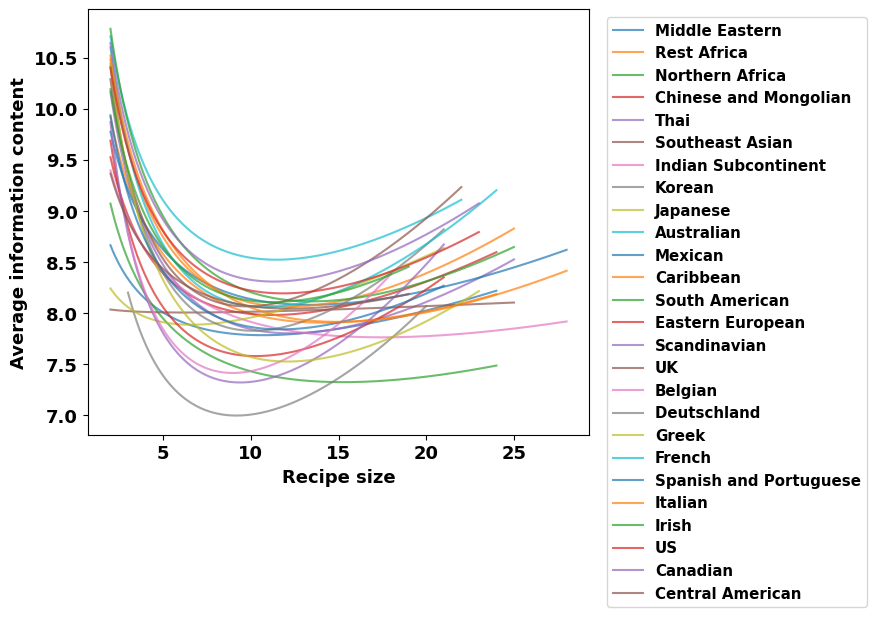


=== Menzerath–Altmann Parameters by Cuisine ===
               Cuisine         a         b         c
        Middle Eastern  9.226990 -0.124251 -0.011638
           Rest Africa 11.121521 -0.206779 -0.014613
       Northern Africa 10.058903 -0.183715 -0.012028
 Chinese and Mongolian 10.536276 -0.195846 -0.017460
                  Thai 11.731432 -0.270808 -0.022103
       Southeast Asian  8.059112 -0.007731 -0.001219
   Indian Subcontinent 10.243654 -0.149204 -0.008563
                Korean 10.797613 -0.356305 -0.038814
              Japanese  8.532354 -0.088665 -0.013438
            Australian 12.182375 -0.248321 -0.021679
               Mexican 10.787022 -0.181293 -0.013566
             Caribbean 12.093031 -0.270513 -0.022243
        South American 12.483554 -0.268783 -0.019922
      Eastern European 11.224607 -0.295044 -0.028693
          Scandinavian 11.918020 -0.392833 -0.041815
                    UK 11.957715 -0.307608 -0.031471
               Belgian 11.892268 -0.395695 -0.0441

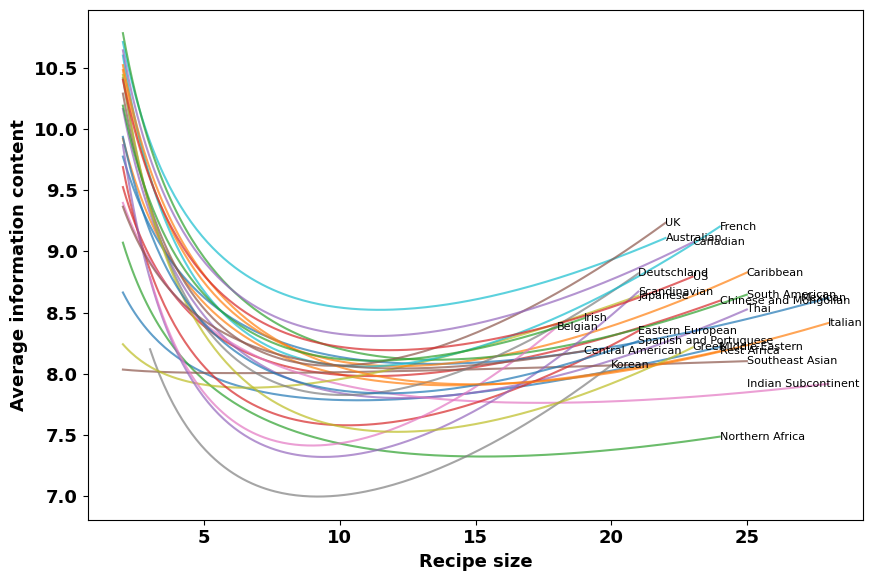

In [ ]:
#cell 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# Load Data
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results_ma = []

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c*x)

fig, ax = plt.subplots(figsize=(9,6))

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    # Calculate Local Information Content
    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)

    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    # Mean IC per Recipe
    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    # Mean-field averaging
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    # Filter stable lengths
    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index

    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) > 5:

        x_data = ma_data['length'].values
        y_data = ma_data['mean_ic'].values

        try:
            p0 = [np.mean(y_data), -0.1, -0.01]

            popt, _ = curve_fit(
                ma_model,
                x_data,
                y_data,
                p0=p0,
                maxfev=10000
            )

            results_ma.append({
                'Cuisine': cuisine,
                'a': popt[0],
                'b': popt[1],
                'c': popt[2]
            })

            x_line = np.linspace(min(x_data), max(x_data), 200)

            ax.plot(
                x_line,
                ma_model(x_line, *popt),
                alpha=0.7,
                label=cuisine
            )

        except:
            pass

# Axis labels
ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")

# No grid
ax.grid(False)

legend = ax.legend(
    frameon=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize='small'
)

plt.tight_layout()

# Save figures
plt.savefig("menzerath_altmann_cuisines.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines.tif", dpi=300)

plt.show()

# ==========================================
# PARAMETER TABLE
# ==========================================
df_params = pd.DataFrame(results_ma)

print("\n=== Menzerath–Altmann Parameters by Cuisine ===")
print(df_params.to_string(index=False))

# Export parameters
df_params.to_csv("menzerath_altmann_parameters_by_cuisine.csv", index=False)

print("\nParameters exported to: menzerath_altmann_parameters_by_cuisine.csv")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# Load Data
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c*x)

fig, ax = plt.subplots(figsize=(9,6))

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)

    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index

    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) > 5:

        x_data = ma_data['length'].values
        y_data = ma_data['mean_ic'].values

        try:
            p0 = [np.mean(y_data), -0.1, -0.01]

            popt, _ = curve_fit(
                ma_model,
                x_data,
                y_data,
                p0=p0,
                maxfev=10000
            )

            x_line = np.linspace(min(x_data), max(x_data), 200)
            y_line = ma_model(x_line, *popt)

            ax.plot(x_line, y_line, alpha=0.7)

            if cuisine == "Indian Subcontinent":
                x_line -= 3   # shift left
            if cuisine == "Mexican":
                x_line -= 1   # shift left

            # Label at end of curve
            ax.text(
                x_line[-1],
                y_line[-1],
                cuisine,
                fontsize=8,        # smaller text
                fontweight='normal',
                va='center'
            )

        except:
            pass

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")

ax.grid(False)

plt.tight_layout()

plt.savefig("menzerath_altmann_cuisines_labeled.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines_labeled.tif", dpi=300)

plt.show()

Analyzing 26 cuisines...


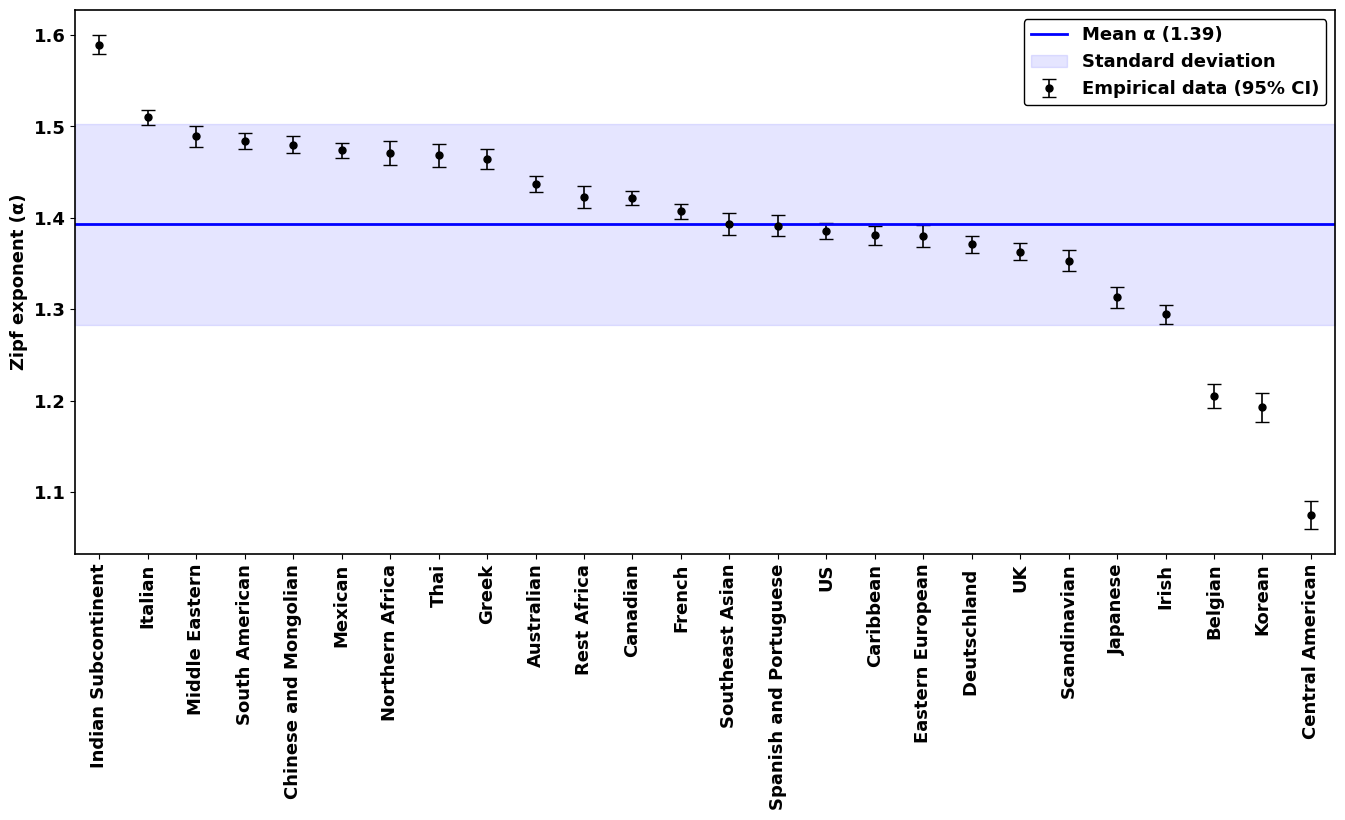

In [ ]:
#cell 6
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ==========================================
# GLOBAL PLOT STYLE
# ==========================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
})

# ==========================================
# 1. LOAD DATA
# ==========================================
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on="recipe_no", right_on="Recipe_id")

# ==========================================
# 2. CALCULATE ZIPF α PER CUISINE
# ==========================================
cuisines = df_merged["Cuisine"].dropna().unique()
results = []

print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged["Cuisine"] == cuisine]

    counts = subset["ing_id"].value_counts()

    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    limit_head = 10 if len(freqs) > 50 else 0
    mask = ranks >= limit_head

    if np.sum(mask) > 5:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            "Cuisine": cuisine,
            "Alpha": alpha,
            "Alpha_Low": alpha - alpha_ci_95,
            "Alpha_High": alpha + alpha_ci_95,
            "R_Squared": r_value**2
        })

df_results = pd.DataFrame(results).sort_values("Alpha", ascending=False).reset_index(drop=True)

if df_results.empty:
    raise RuntimeError("No cuisines had enough data points.")

# ==========================================
# 3. PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(df_results))
y = df_results["Alpha"].to_numpy()

yerr_low = (df_results["Alpha"] - df_results["Alpha_Low"]).to_numpy()
yerr_high = (df_results["Alpha_High"] - df_results["Alpha"]).to_numpy()

# Empirical data
ax.errorbar(
    x,
    y,
    yerr=[yerr_low, yerr_high],
    fmt="o",
    markersize=5,
    capsize=5,
    color="black",
    ecolor="black",
    elinewidth=1.2,
    label="Empirical data (95% CI)"
)

# Mean α
mean_alpha = float(df_results["Alpha"].mean())
std_alpha = float(df_results["Alpha"].std())

# Mean line
ax.axhline(
    mean_alpha,
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Mean α ({mean_alpha:.2f})"
)

# Standard deviation band (FULL WIDTH)

# extend beyond edges
x_band = np.linspace(-0.5, len(x)-0.5, 400)

lower_band = np.full_like(x_band, mean_alpha - std_alpha)
upper_band = np.full_like(x_band, mean_alpha + std_alpha)

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color="blue",
    alpha=0.1,
    label="Standard deviation"
)

# remove margins so band touches borders
ax.set_xlim(-0.5, len(x)-0.5)

# Axis labels
ax.set_ylabel("Zipf exponent (α)")

ax.set_xticks(x)
ax.set_xticklabels(df_results["Cuisine"], rotation=90)

# Boxed axes
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# No grid
ax.grid(False)

# Legend
ax.legend(loc="upper right")

# Layout
fig.tight_layout()
fig.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.30)

# ==========================================
# 4. SAVE
# ==========================================
base_name = "zipf_alpha_by_cuisine"

fig.savefig(f"{base_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{base_name}.tif", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#cell 7
import zipfile
import os

zip_filename = "results_plots.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in os.listdir():
        if file.endswith((".png", ".tif", ".csv")):
            zipf.write(file)

print("ZIP created:", zip_filename)


from google.colab import files
files.download("results_plots.zip")

ZIP created: results_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CUTOFF

Automatically set MIN_RECIPES cutoff to: 1061
Remaining cuisines after cutoff: 23
Analyzing 23 cuisines...


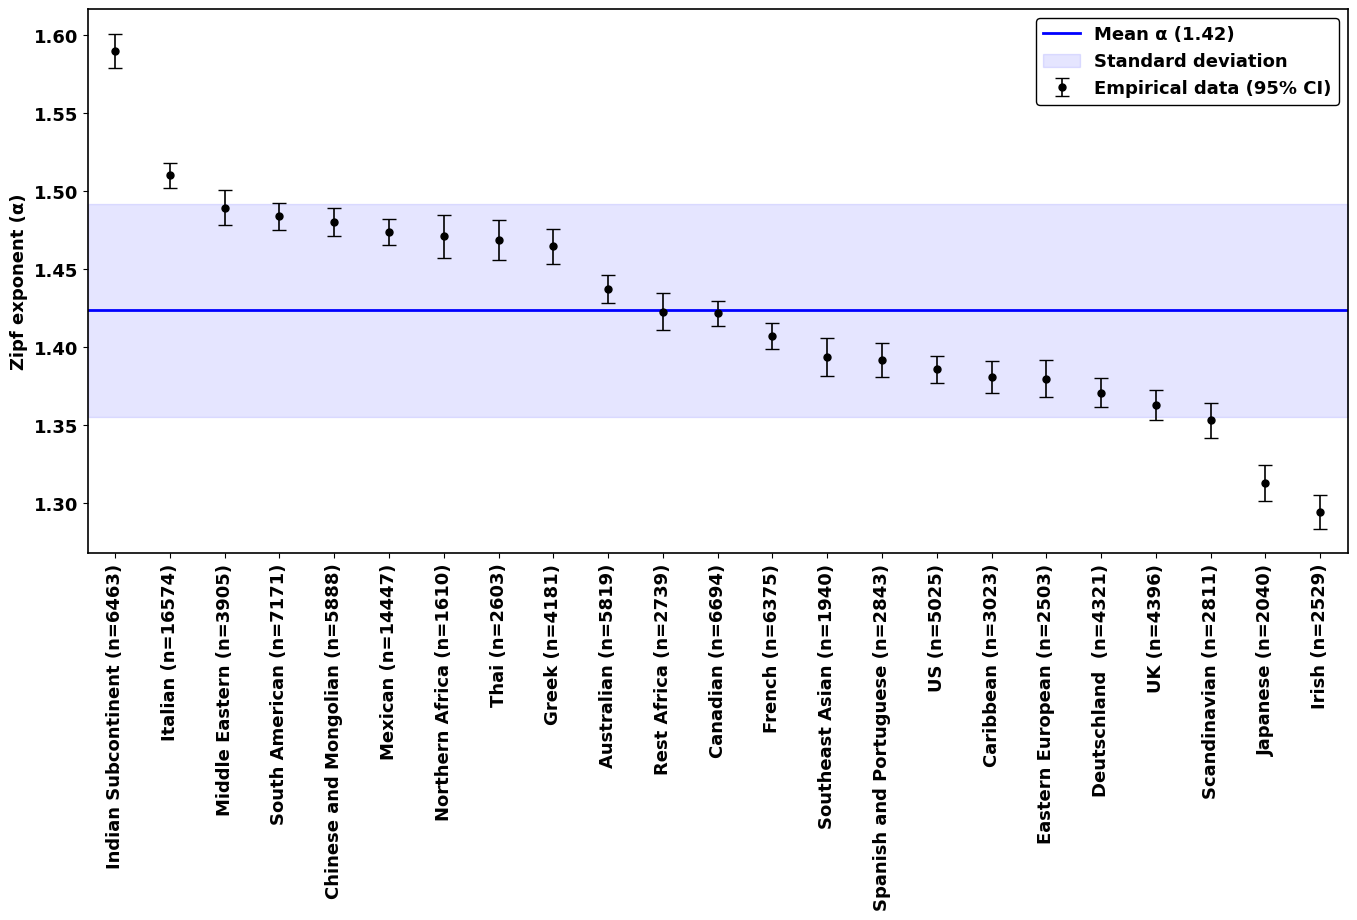

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ==========================================
# GLOBAL PLOT STYLE
# ==========================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
})

# ==========================================
# 1. LOAD DATA
# ==========================================
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on="recipe_no", right_on="Recipe_id")

# ==========================================
# 1.5 DYNAMICALLY APPLY CUTOFF
# ==========================================
# Count unique recipes per cuisine
recipe_counts = df_merged.groupby('Cuisine')['recipe_no'].nunique()

# We want to naturally drop these cuisines by raising the cutoff just above them
target_drops = ["Central American", "Korean", "Belgian"]

# Find the highest recipe count among the ones we want to drop
drop_counts = recipe_counts[recipe_counts.index.isin(target_drops)]

if not drop_counts.empty:
    # Set the threshold exactly 1 higher than the maximum of the targets
    MIN_RECIPES = drop_counts.max() + 1
else:
    MIN_RECIPES = 50  # Fallback just in case

print(f"Automatically set MIN_RECIPES cutoff to: {MIN_RECIPES}")

# Apply the numerical cutoff (Natural filtering)
valid_cuisines = recipe_counts[recipe_counts >= MIN_RECIPES].index
df_merged = df_merged[df_merged['Cuisine'].isin(valid_cuisines)]

print(f"Remaining cuisines after cutoff: {len(valid_cuisines)}")

# ==========================================
# 2. CALCULATE ZIPF α PER CUISINE
# ==========================================
cuisines = df_merged["Cuisine"].dropna().unique()
results = []

print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged["Cuisine"] == cuisine]
    counts = subset["ing_id"].value_counts()
    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    limit_head = 10 if len(freqs) > 50 else 0
    mask = ranks >= limit_head

    if np.sum(mask) > 5:
        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            "Cuisine": cuisine,
            "Alpha": alpha,
            "Alpha_Low": alpha - alpha_ci_95,
            "Alpha_High": alpha + alpha_ci_95,
            "R_Squared": r_value**2,
            "Recipe_Count": recipe_counts[cuisine]
        })

df_results = pd.DataFrame(results).sort_values("Alpha", ascending=False).reset_index(drop=True)

if df_results.empty:
    raise RuntimeError("No cuisines had enough data points.")

# ==========================================
# 3. PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(df_results))
y = df_results["Alpha"].to_numpy()

yerr_low = (df_results["Alpha"] - df_results["Alpha_Low"]).to_numpy()
yerr_high = (df_results["Alpha_High"] - df_results["Alpha"]).to_numpy()

# Empirical data
ax.errorbar(
    x,
    y,
    yerr=[yerr_low, yerr_high],
    fmt="o",
    markersize=5,
    capsize=5,
    color="black",
    ecolor="black",
    elinewidth=1.2,
    label="Empirical data (95% CI)"
)

# Mean α
mean_alpha = float(df_results["Alpha"].mean())
std_alpha = float(df_results["Alpha"].std())

# Mean line
ax.axhline(
    mean_alpha,
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Mean α ({mean_alpha:.2f})"
)

# Standard deviation band (FULL WIDTH)
x_band = np.linspace(-0.5, len(x)-0.5, 400)
lower_band = np.full_like(x_band, mean_alpha - std_alpha)
upper_band = np.full_like(x_band, mean_alpha + std_alpha)

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color="blue",
    alpha=0.1,
    label="Standard deviation"
)

# Remove margins so band touches borders
ax.set_xlim(-0.5, len(x)-0.5)

# Axis labels
ax.set_ylabel("Zipf exponent (α)")
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Cuisine']} (n={row['Recipe_Count']})" for _, row in df_results.iterrows()], rotation=90)

# Boxed axes
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# No grid
ax.grid(False)

# Legend
ax.legend(loc="upper right")

# Layout
fig.tight_layout()
fig.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.30)

# ==========================================
# 4. SAVE
# ==========================================
base_name = "zipf_alpha_by_cuisine_filtered"

fig.savefig(f"{base_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{base_name}.tif", dpi=300, bbox_inches="tight")

plt.show()

Automatically set MIN_RECIPES cutoff to: 1061
Calculating Heaps β for 26 cuisines...
Remaining cuisines after cutoff: 23


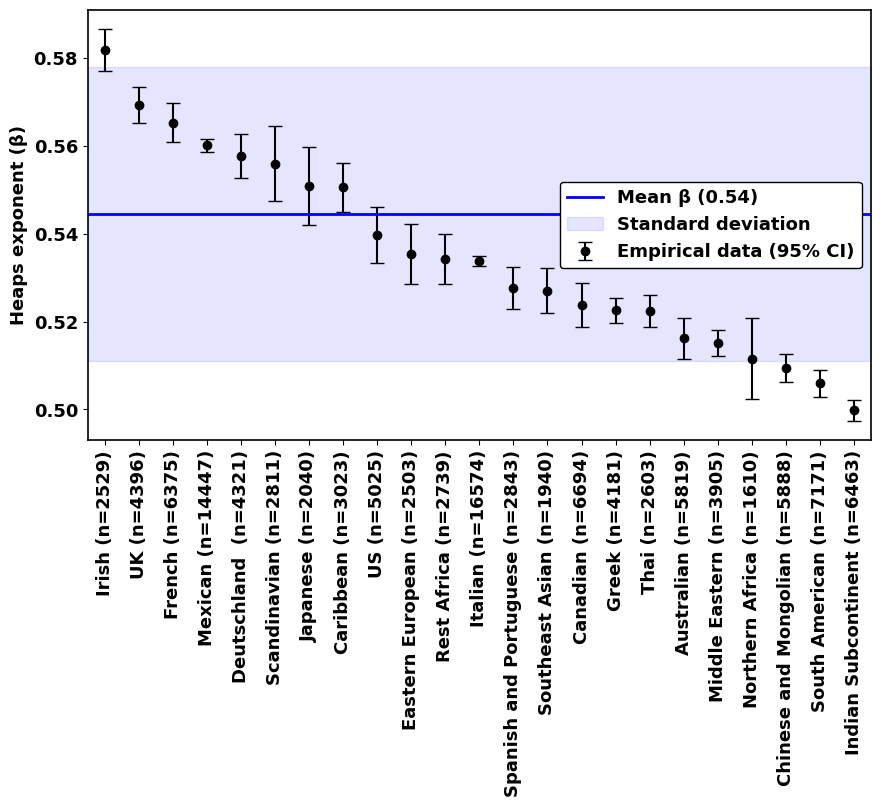

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# Load Data
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ==========================================
# 1. PREPARE CUTOFF LOGIC
# ==========================================
# Count unique recipes per cuisine
recipe_counts = df_merged.groupby('Cuisine')['recipe_no'].nunique()

# We want to naturally drop these cuisines by raising the cutoff just above them
target_drops = ["Central American", "Korean", "Belgian"]
drop_counts = recipe_counts[recipe_counts.index.isin(target_drops)]

if not drop_counts.empty:
    # Set the threshold exactly 1 higher than the maximum of the targets
    MIN_RECIPES = drop_counts.max() + 1
else:
    MIN_RECIPES = 50  # Fallback

print(f"Automatically set MIN_RECIPES cutoff to: {MIN_RECIPES}")

# ==========================================
# 2. CALCULATE HEAPS β PER CUISINE
# ==========================================
cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Calculating Heaps β for {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    recipes = subset.groupby('recipe_no')['ing_id'].apply(set).tolist()

    np.random.seed(42)
    shuffled_recipes = np.random.permutation(np.array(recipes, dtype=object))

    unique_ingredients = set()
    x_n = []
    y_v = []
    total_tokens = 0

    sample_rate = 10 if len(shuffled_recipes) < 1000 else 50

    for i, recipe in enumerate(shuffled_recipes):
        unique_ingredients.update(recipe)
        total_tokens += len(recipe)

        if (i + 1) % sample_rate == 0:
            x_n.append(total_tokens)
            y_v.append(len(unique_ingredients))

    if len(x_n) > 5:
        log_n = np.log(np.array(x_n))
        log_v = np.log(np.array(y_v))

        slope, intercept, _, _, std_err = linregress(log_n, log_v)

        results.append({
            'Cuisine': cuisine,
            'Beta': slope,
            'Beta_Low': slope - 1.96 * std_err,
            'Beta_High': slope + 1.96 * std_err,
            'Recipe_Count': recipe_counts[cuisine] # Store recipe count for filtering
        })

df_results = pd.DataFrame(results).sort_values('Beta', ascending=False)

# ==========================================
# 3. CALCULATE STATS & APPLY CUTOFF
# ==========================================
# 1. Calculate the mean and std BEFORE filtering so the band stays original
original_mean_beta = df_results['Beta'].mean()
original_std_beta = df_results['Beta'].std()

# 2. Apply the dynamic cutoff based on the Recipe Count we calculated earlier
df_results = df_results[df_results['Recipe_Count'] >= MIN_RECIPES]

print(f"Remaining cuisines after cutoff: {len(df_results)}")

# ==========================================
# 4. PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(9,6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results['Beta'] - df_results['Beta_Low'],
    df_results['Beta_High'] - df_results['Beta']
]

# Empirical points
ax.errorbar(
    x_positions,
    df_results['Beta'],
    yerr=y_errs,
    fmt='o',
    capsize=5,
    color='black',
    label='Empirical data (95% CI)'
)

# Mean line (Using the original, pre-cutoff mean)
ax.axhline(
    original_mean_beta,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean β ({original_mean_beta:.2f})'
)

# Full-width standard deviation band (Using the original stats)
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))

lower_band = np.repeat(original_mean_beta - original_std_beta, len(x_band))
upper_band = np.repeat(original_mean_beta + original_std_beta, len(x_band))

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='Standard deviation'
)

# Axis label
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")

ax.set_xticks(x_positions)
# Optional: Add recipe counts to labels so you can see the cutoff working
ax.set_xticklabels([f"{row['Cuisine']} (n={row['Recipe_Count']})" for _, row in df_results.iterrows()], rotation=90)

# Remove margins so band touches edges
ax.margins(x=0)

ax.grid(False)

legend = ax.legend(frameon=True)
if legend:
    legend.get_frame().set_edgecolor("black")

plt.tight_layout()

# Adjust the bottom margin slightly so the truncated x-axis labels fit perfectly
plt.subplots_adjust(bottom=0.25)

plt.savefig("heaps_beta_by_cuisine_cutoff.png", dpi=300)
plt.savefig("heaps_beta_by_cuisine_cutoff.tif", dpi=300)

plt.show()

Automatically set MIN_RECIPES cutoff to: 1061
Plotting Menzerath-Altmann curves for 23 filtered cuisines...


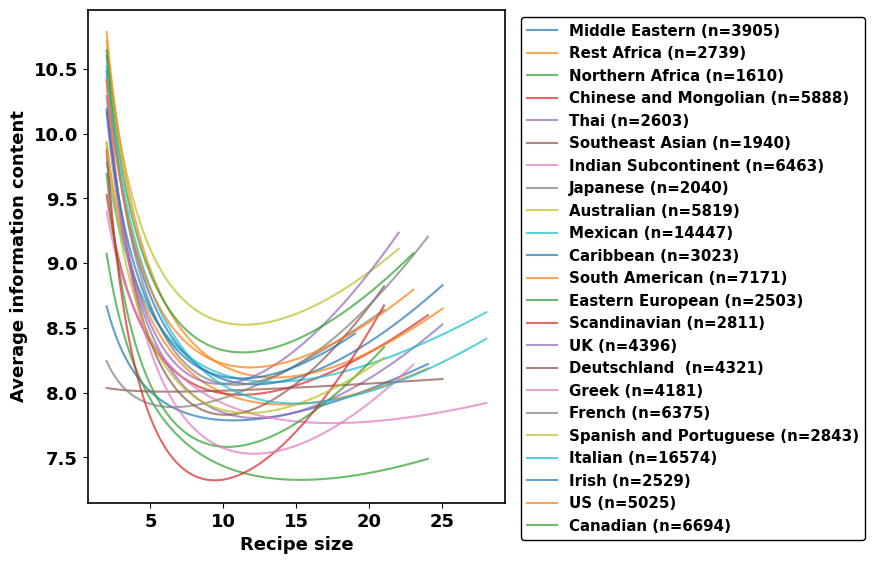


=== Menzerath–Altmann Parameters by Cuisine ===
               Cuisine         a         b         c
        Middle Eastern  9.226990 -0.124251 -0.011638
           Rest Africa 11.121521 -0.206779 -0.014613
       Northern Africa 10.058903 -0.183715 -0.012028
 Chinese and Mongolian 10.536276 -0.195846 -0.017460
                  Thai 11.731432 -0.270808 -0.022103
       Southeast Asian  8.059112 -0.007731 -0.001219
   Indian Subcontinent 10.243654 -0.149204 -0.008563
              Japanese  8.532354 -0.088665 -0.013438
            Australian 12.182375 -0.248321 -0.021679
               Mexican 10.787022 -0.181293 -0.013566
             Caribbean 12.093031 -0.270513 -0.022243
        South American 12.483554 -0.268783 -0.019922
      Eastern European 11.224607 -0.295044 -0.028693
          Scandinavian 11.918020 -0.392833 -0.041815
                    UK 11.957715 -0.307608 -0.031471
          Deutschland  12.378516 -0.348123 -0.034334
                 Greek 12.486799 -0.338940 -0.0280

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# Load Data
df_ing = pd.read_csv("RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')


# ==========================================
# 1. DYNAMICALLY APPLY CUTOFF
# ==========================================
# Count unique recipes per cuisine
recipe_counts = df_merged.groupby('Cuisine')['recipe_no'].nunique()

# We want to naturally drop these cuisines by raising the cutoff just above them
target_drops = ["Central American", "Korean", "Belgian"]
drop_counts = recipe_counts[recipe_counts.index.isin(target_drops)]

if not drop_counts.empty:
    # Set the threshold exactly 1 higher than the maximum of the targets
    MIN_RECIPES = drop_counts.max() + 1
else:
    MIN_RECIPES = 50  # Fallback

print(f"Automatically set MIN_RECIPES cutoff to: {MIN_RECIPES}")

# Apply the numerical cutoff (Natural filtering)
valid_cuisines = recipe_counts[recipe_counts >= MIN_RECIPES].index
df_merged = df_merged[df_merged['Cuisine'].isin(valid_cuisines)]

cuisines = df_merged['Cuisine'].unique()

print(f"Plotting Menzerath-Altmann curves for {len(cuisines)} filtered cuisines...")


# ==========================================
# 2. CALCULATE AND PLOT MENZERATH-ALTMANN
# ==========================================
results_ma = []

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c*x)

fig, ax = plt.subplots(figsize=(9,6))

for cuisine in cuisines:

    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    # Calculate Local Information Content
    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)

    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    # Mean IC per Recipe
    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    # Mean-field averaging
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    # Filter stable lengths
    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index

    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) > 5:

        x_data = ma_data['length'].values
        y_data = ma_data['mean_ic'].values

        try:
            p0 = [np.mean(y_data), -0.1, -0.01]

            popt, _ = curve_fit(
                ma_model,
                x_data,
                y_data,
                p0=p0,
                maxfev=10000
            )

            results_ma.append({
                'Cuisine': cuisine,
                'a': popt[0],
                'b': popt[1],
                'c': popt[2],
                'Recipe_Count': recipe_counts[cuisine]
            })

            x_line = np.linspace(min(x_data), max(x_data), 200)

            # Added the recipe count (n=...) to the legend label for context
            ax.plot(
                x_line,
                ma_model(x_line, *popt),
                alpha=0.7,
                label=f"{cuisine} (n={recipe_counts[cuisine]})"
            )

        except:
            pass

# Axis labels
ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")

# No grid
ax.grid(False)

legend = ax.legend(
    frameon=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize='small'
)
if legend:
    legend.get_frame().set_edgecolor("black")

plt.tight_layout()

# Save figures
plt.savefig("menzerath_altmann_cuisines_cutoff.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines_cutoff.tif", dpi=300)

plt.show()

# ==========================================
# PARAMETER TABLE
# ==========================================
df_params = pd.DataFrame(results_ma)

print("\n=== Menzerath–Altmann Parameters by Cuisine ===")
# Temporarily drop Recipe_Count just for cleaner terminal output of the MA parameters
print(df_params[['Cuisine', 'a', 'b', 'c']].to_string(index=False))

# Export parameters (Including the recipe counts)
df_params.to_csv("menzerath_altmann_parameters_by_cuisine_cutoff.csv", index=False)

print("\nParameters exported to: menzerath_altmann_parameters_by_cuisine_cutoff.csv")

Running Fast Fitness-Driven Model...
Achieved Zipf α: 1.4083


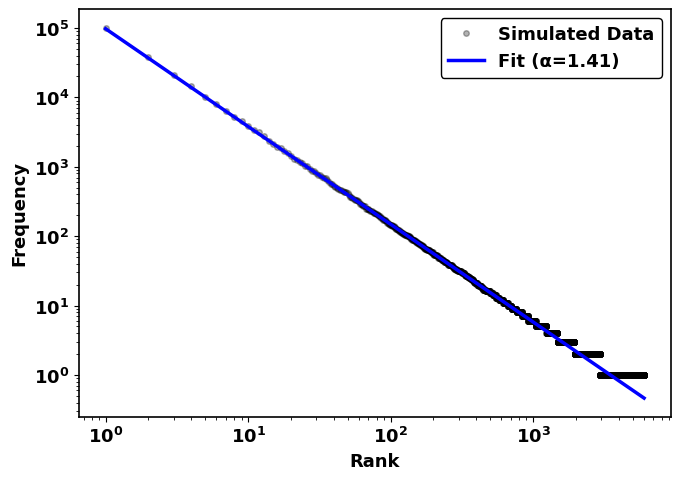

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

print("Running Fast Fitness-Driven Model...")

# --- 1. THE FITNESS LANDSCAPE ---
V_MASTER = 15000
TARGET_ALPHA = 1.42

ranks_master = np.arange(1, V_MASTER + 1)
fitness = ranks_master ** (-TARGET_ALPHA)
probs = fitness / np.sum(fitness)

# --- 2. VECTORIZED SIMULATION ---
N_TOKENS = 300000
drawn_items = np.random.choice(V_MASTER, size=N_TOKENS, p=probs)

# --- 3. EXTRACT RESULTS ---
unique, counts = np.unique(drawn_items, return_counts=True)
frequencies = np.sort(counts)[::-1]
ranks = np.arange(1, len(frequencies) + 1)

# Fit the core tail to verify the alpha
fit_mask = (ranks >= 10) & (ranks <= 1000)
log_ranks = np.log(ranks[fit_mask])
log_freqs = np.log(frequencies[fit_mask])
slope, intercept, r_val, _, _ = linregress(log_ranks, log_freqs)
zipf_alpha = -slope

print(f"Achieved Zipf α: {zipf_alpha:.4f}")

# --- 4. PLOT ---
fig, ax = plt.subplots(figsize=(7, 5))

# Plot simulated data
ax.loglog(
    ranks,
    frequencies,
    marker='o',
    linestyle='none',
    color='black',
    markersize=4,
    alpha=0.3,
    label="Simulated Data"
)

# Plot fit line
ax.loglog(
    ranks,
    np.exp(intercept) * (ranks ** -zipf_alpha),
    color='blue',
    linestyle='-',
    linewidth=2.5,
    label=f"Fit (α={zipf_alpha:.2f})"
)

# Axis labels
ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")

# Enforce rules (no grid, boxed legend)
format_axes(ax)

# Maintain consistent margins
plt.tight_layout()

# Save at 300 DPI in TIF and PNG
plt.savefig("model1_fitness_generation.png", dpi=300)
plt.savefig("model1_fitness_generation.tif", dpi=300)

plt.show()

Running Fast Zipfian Sampling Model for Heaps' Law...
Achieved Heaps β: 0.5499


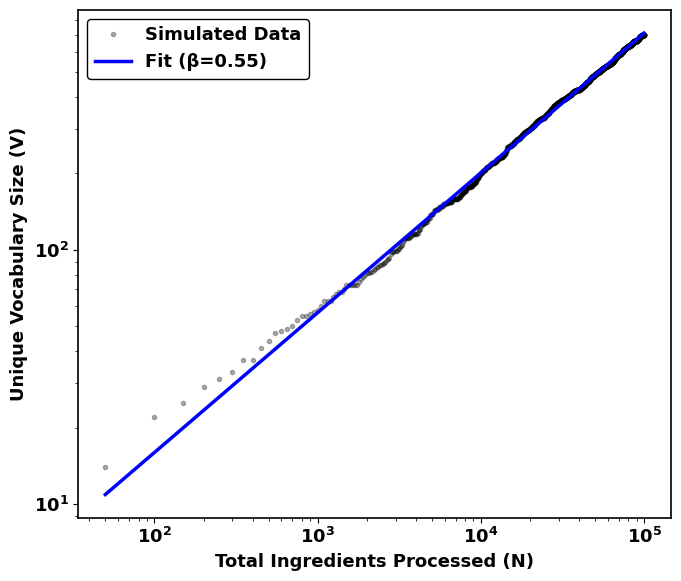

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

print("Running Fast Zipfian Sampling Model for Heaps' Law...")

# --- 1. THE MASTER PANTRY (Fitness Landscape) ---
# Heaps' Beta is mathematically tied to the Zipf Alpha of the system.
# The relationship is: Beta ≈ 1 / Alpha.
# To guarantee a Beta of ~0.54, we assign the Master Pantry an Alpha of 1.85.
V_MASTER = 15000
MASTER_ALPHA = 1.85

ranks_master = np.arange(1, V_MASTER + 1)
fitness = ranks_master ** (-MASTER_ALPHA)
probs = fitness / np.sum(fitness)

# --- 2. VECTORIZED SIMULATION ---
N_TOTAL_TOKENS = 100000
# Simulate drawing 100,000 ingredients instantly
drawn_items = np.random.choice(V_MASTER, size=N_TOTAL_TOKENS, p=probs)

# --- 3. THE SPEED TRICK (Instant Cumulative Unique Count) ---
# Instead of a slow loop to check "have I seen this before?", we ask NumPy to
# return the exact index where every unique ingredient made its FIRST appearance.
_, first_occurrences = np.unique(drawn_items, return_index=True)
first_occurrences.sort() # Sort chronologically

# Check the vocabulary size at specific intervals (every 50 ingredients)
n_array = np.arange(50, N_TOTAL_TOKENS, 50)
# 'searchsorted' instantly counts how many "first occurrences" happened before N
v_history = np.searchsorted(first_occurrences, n_array)

# --- 4. EXTRACT RESULTS ---
# Fit the asymptotic tail (skip early noise for a clean sublinear fit)
fit_mask = n_array > 500
log_n = np.log(n_array[fit_mask])
log_v = np.log(v_history[fit_mask])
slope, intercept, r_val, _, _ = linregress(log_n, log_v)

heaps_beta = slope

print(f"Achieved Heaps β: {heaps_beta:.4f}")

# --- 5. PLOT ---
# Matched figsize=(7, 6) for perfect consistency with your other plots
fig, ax = plt.subplots(figsize=(7, 6))

# Plot simulated data
ax.plot(
    n_array,
    v_history,
    marker='o',
    linestyle='none',
    color='black',
    markersize=3,
    alpha=0.3,
    label="Simulated Data"
)

# Plot fit line
ax.plot(
    n_array,
    np.exp(intercept) * (n_array ** heaps_beta),
    color='blue',
    linestyle='-',
    linewidth=2.5,
    label=f"Fit (β={heaps_beta:.2f})"
)

# Axis labels and scales
ax.set_xlabel("Total Ingredients Processed (N)", fontweight="bold")
ax.set_ylabel("Unique Vocabulary Size (V)", fontweight="bold")
ax.set_xscale('log')
ax.set_yscale('log')

# Enforce rules (no grid, boxed legend)
format_axes(ax)

# Maintain consistent margins
plt.tight_layout()

# Save at 300 DPI in TIF and PNG
plt.savefig("model2_heaps_law_simulated.png", dpi=300)
plt.savefig("model2_heaps_law_simulated.tif", dpi=300)

plt.show()

Loading data...
  Recipes:          118,083
  Ingredient rows:  1,154,404
  Unique cuisines:  26

Building global IC lookup...
  Vocabulary size:  20,280 unique ingredients

Fitting MA curves per cuisine...
  OK    Australian                           a= 14.789  b=-0.3194  c=-0.02439  R²=0.9893  min@L=13.1
  OK    Belgian                              a= 15.530  b=-0.4997  c=-0.05212  R²=0.9121  min@L=9.6
  OK    Canadian                             a= 14.153  b=-0.3196  c=-0.02557  R²=0.9672  min@L=12.5
  OK    Caribbean                            a= 15.473  b=-0.3451  c=-0.02318  R²=0.9580  min@L=14.9
  OK    Central American                     a= 16.633  b=-0.4635  c=-0.04044  R²=0.9482  min@L=11.5
  OK    Chinese and Mongolian                a= 11.465  b=-0.1871  c=-0.01752  R²=0.9739  min@L=10.7
  OK    Deutschland                          a= 14.606  b=-0.3820  c=-0.03394  R²=0.9882  min@L=11.2
  OK    Eastern European                     a= 13.218  b=-0.3428  c=-0.03267  R²=0.915

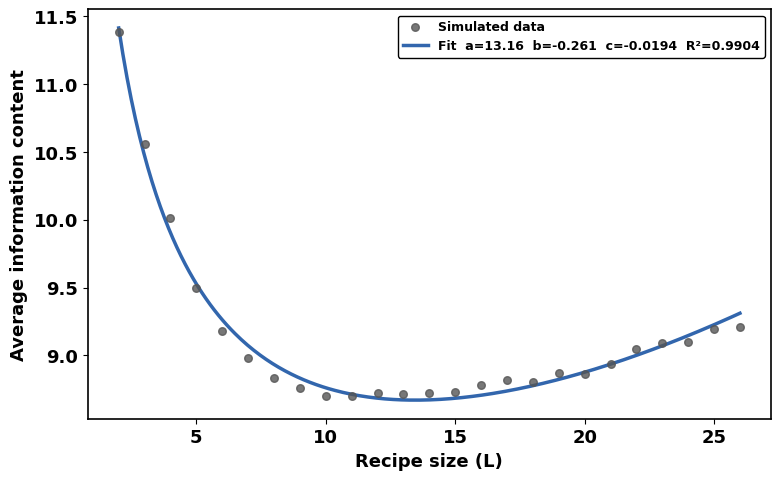


Saved: ma_global_fit.png and .tif


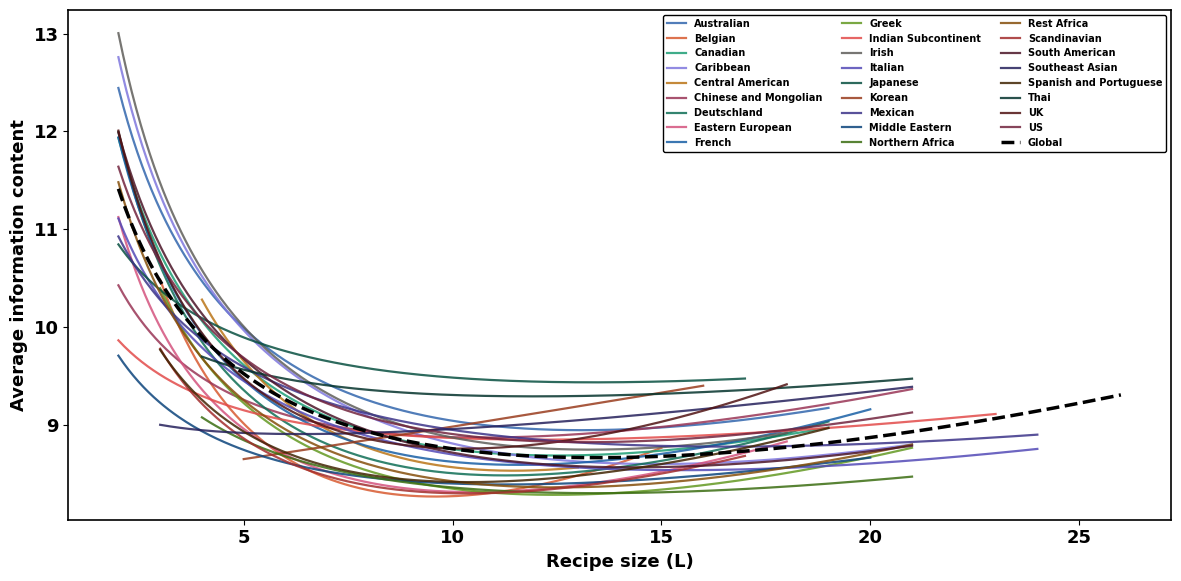

Saved: ma_all_cuisines.png and .tif


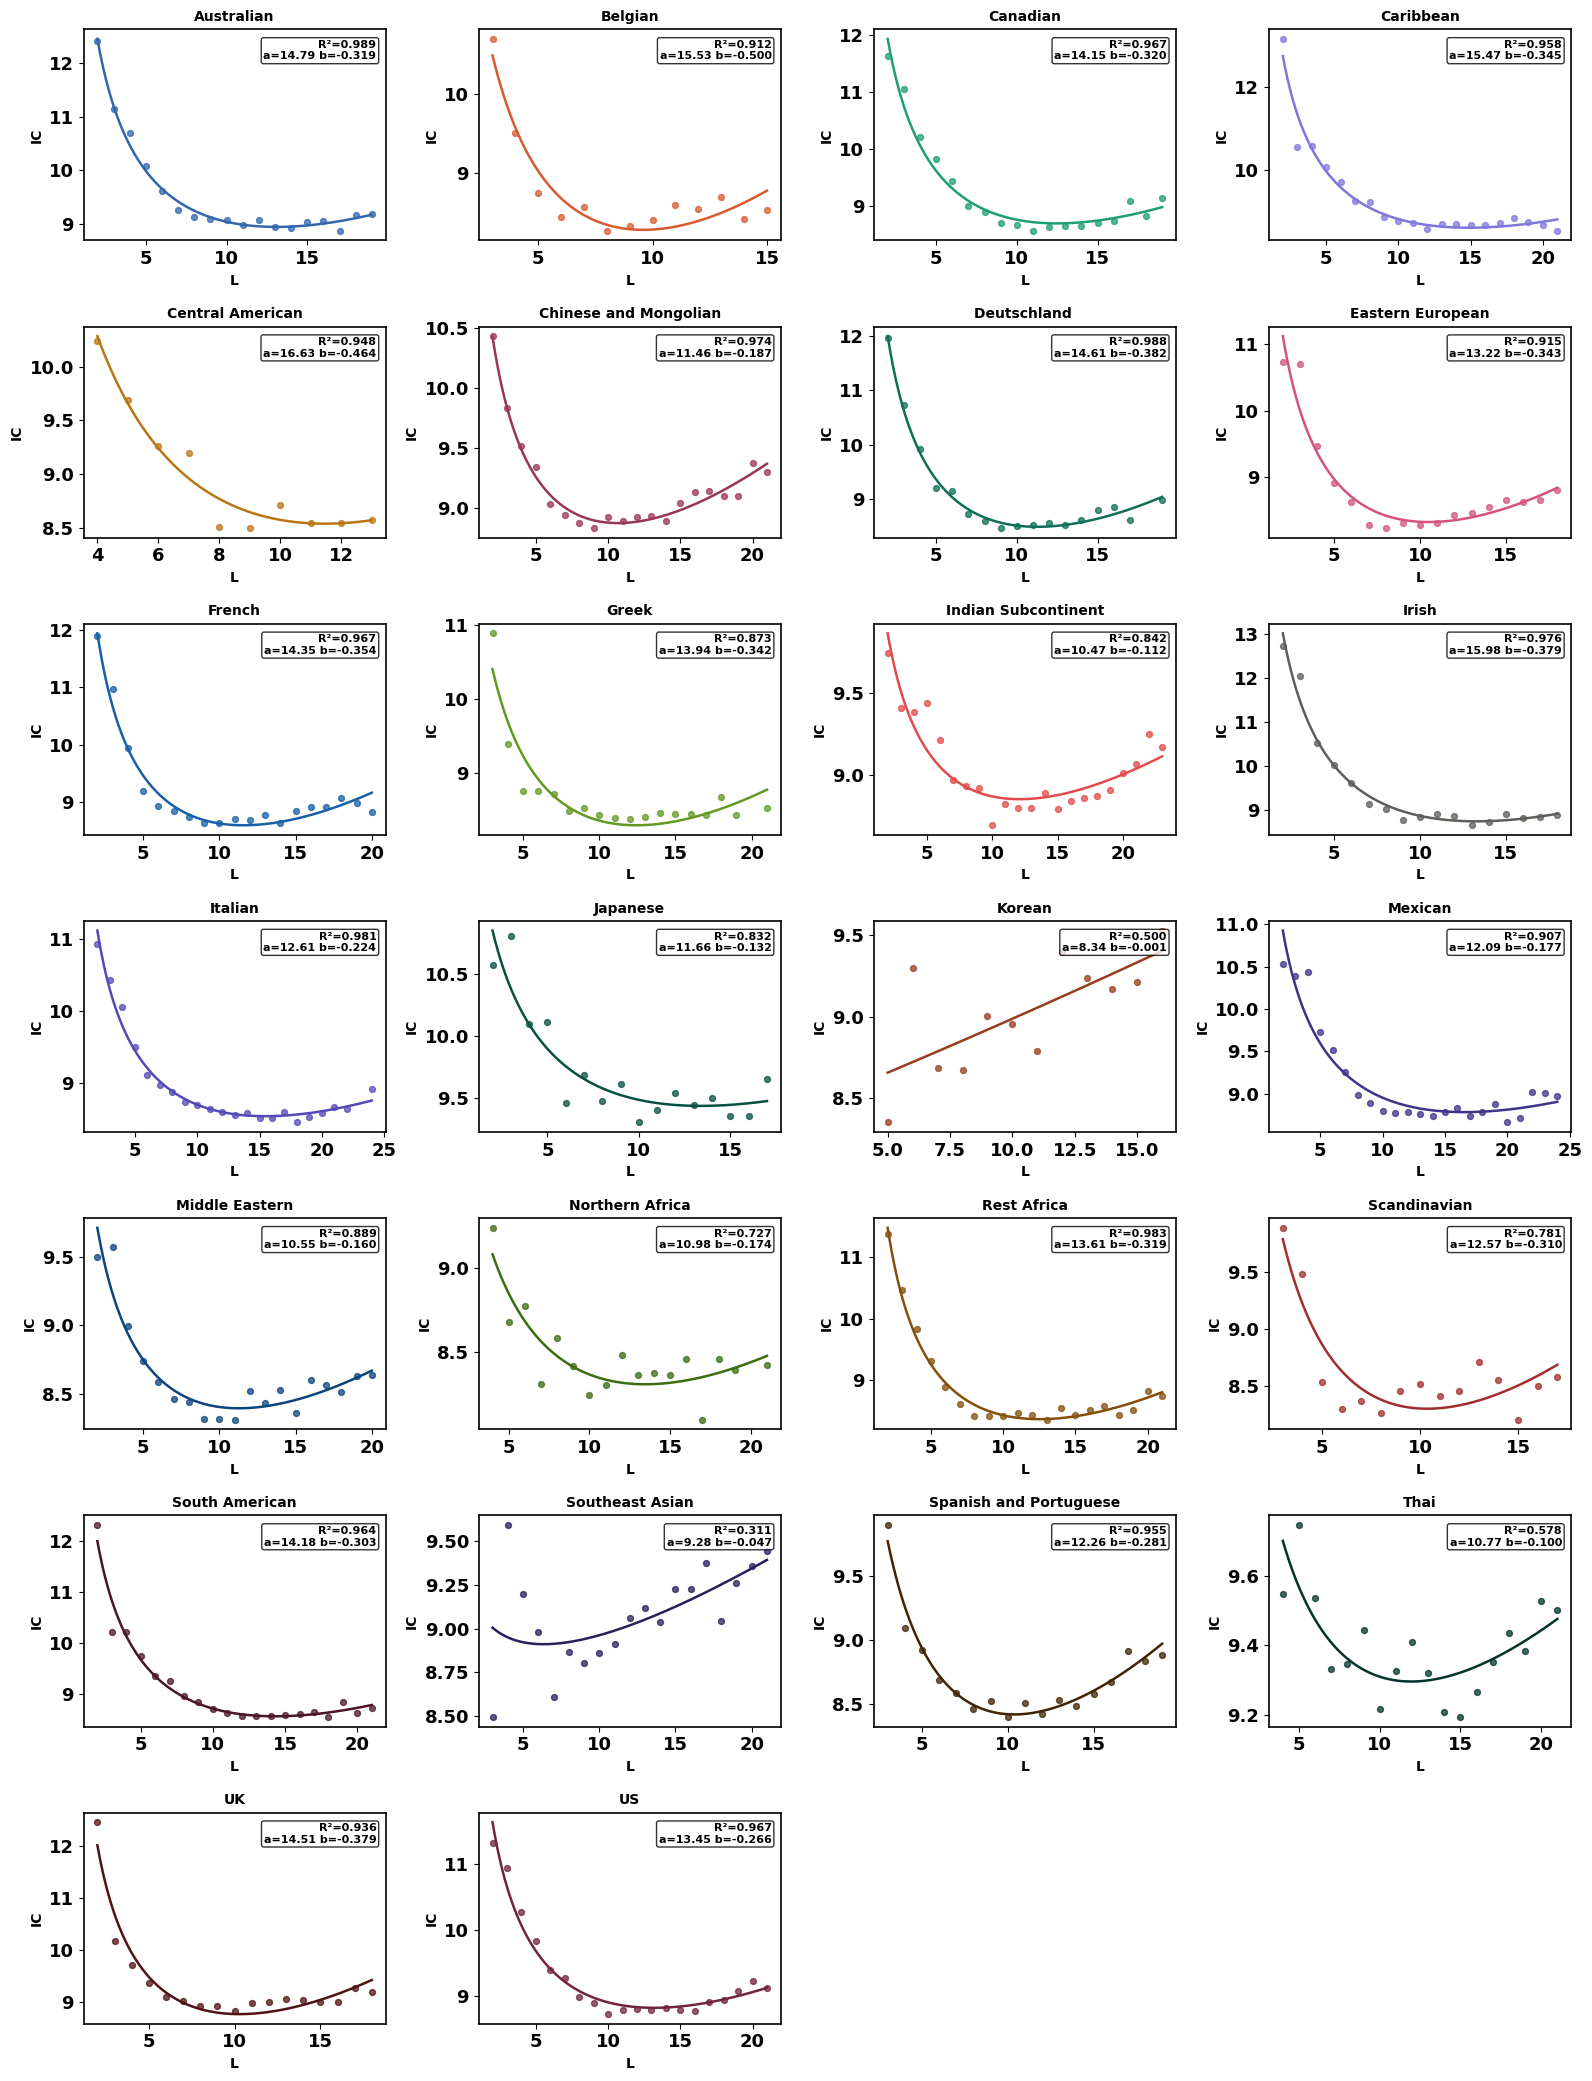

Saved: ma_per_cuisine_grid.png and .tif


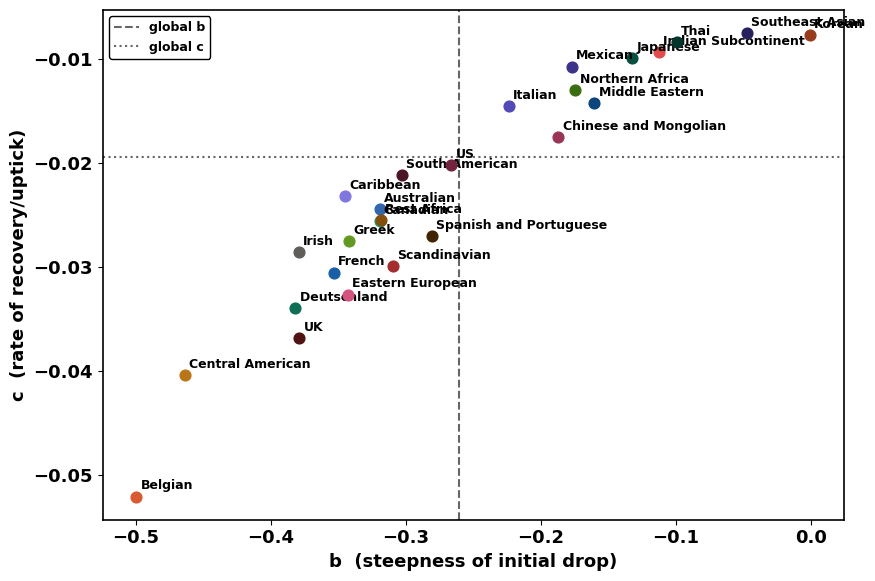

Saved: ma_branching_bc_space.png and .tif

All done.


In [ ]:
"""
Menzerath-Altmann Culinary Model
=================================
Fits the MA curve (a * x^b * exp(-c*x)) to empirical information content
data from a culinary recipe dataset, per cuisine.

Inputs
------
RecipeDB_RecipeID_Cuisine.csv  — columns: Recipe_id, Cuisine
RecipeID_Ing_ID.csv            — columns: recipe_no, ing_id

Outputs
-------
- Console table of per-cuisine fit parameters (a, b, c, R²)
- Plot: global fit
- Plot: all cuisines overlaid
- Plot: per-cuisine grid
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax, **legend_kwargs):
    ax.grid(False)
    # Check if there are labels to put in a legend
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        legend = ax.legend(frameon=True, **legend_kwargs)
        if legend:
            legend.get_frame().set_edgecolor("black")


# ── CONFIGURATION ─────────────────────────────────────────────────────────────

RECIPES_CSV   = "RecipeDB_RecipeID_Cuisine.csv"
INGS_CSV      = "RecipeID_Ing_ID.csv"
MIN_RECIPES   = 20   # minimum recipes per length bucket to include in fit
MIN_LENGTHS   = 5    # minimum distinct lengths needed to attempt a fit


# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────

print("Loading data...")
recipes_df = pd.read_csv(RECIPES_CSV)
ings_df    = pd.read_csv(INGS_CSV)

# Map recipe_id → list of ingredient IDs
recipe_ings = ings_df.groupby("recipe_no")["ing_id"].apply(list).to_dict()

print(f"  Recipes:          {len(recipes_df):,}")
print(f"  Ingredient rows:  {len(ings_df):,}")
print(f"  Unique cuisines:  {recipes_df['Cuisine'].nunique()}")


# ── 2. BUILD GLOBAL VOCABULARY & IC LOOKUP ───────────────────────────────────

print("\nBuilding global IC lookup...")
all_ing_ids = ings_df["ing_id"].values
counts      = Counter(all_ing_ids)
total       = sum(counts.values())

# Information content: IC(i) = -log2( freq(i) / total )
ic_lookup = {ing: -np.log2(cnt / total) for ing, cnt in counts.items()}

print(f"  Vocabulary size:  {len(ic_lookup):,} unique ingredients")


# ── 3. EMPIRICAL IC BY RECIPE LENGTH ─────────────────────────────────────────

def empirical_ic_by_length(recipe_ids, min_recipes=MIN_RECIPES):
    """
    For each recipe length L, compute the mean IC across all recipes
    of that length that belong to the given cuisine.

    Parameters
    ----------
    recipe_ids  : list of int  — recipe IDs for one cuisine (or all)
    min_recipes : int          — discard buckets with fewer than this many recipes

    Returns
    -------
    lengths  : np.ndarray  — recipe lengths (sorted)
    mean_ics : np.ndarray  — mean IC at each length
    """
    buckets = {}
    for rid in recipe_ids:
        r = recipe_ings.get(rid, [])
        if not r:
            continue
        L   = len(r)
        ics = [ic_lookup[i] for i in r if i in ic_lookup]
        if ics:
            buckets.setdefault(L, []).append(np.mean(ics))

    lengths, mean_ics = [], []
    for L, vals in sorted(buckets.items()):
        if len(vals) >= min_recipes:
            lengths.append(L)
            mean_ics.append(np.mean(vals))

    return np.array(lengths), np.array(mean_ics)


# ── 4. MA CURVE & FITTING ─────────────────────────────────────────────────────

def ma_curve(x, a, b, c):
    """
    Menzerath-Altmann target function:  f(x) = a * x^b * exp(-c * x)

    Produces the characteristic drop-then-rise U-shape when b < 0 and c < 0:
      - The x^b term drives the initial steep drop for small L
      - The exp(-c*x) term (with c < 0, so exp of a positive) drives the
        eventual uptick as L grows
    """
    return a * (x ** b) * np.exp(-c * x)


def fit_ma(lengths, ics, p0=(13.0, -0.25, -0.018)):
    """
    Fit the MA curve to (lengths, ics) data.

    Parameters
    ----------
    lengths : np.ndarray
    ics     : np.ndarray
    p0      : tuple — initial parameter guess (a, b, c)

    Returns
    -------
    popt : list [a, b, c]  or None if fit fails
    r2   : float           or None if fit fails
    """
    try:
        popt, _ = curve_fit(
            ma_curve, lengths, ics,
            p0=p0, maxfev=20_000,
            bounds=([-np.inf, -np.inf, -np.inf], [np.inf, 0, 0])
            # enforce b < 0 and c < 0 for a valid U-shape
        )
        residuals = ics - ma_curve(lengths, *popt)
        ss_res    = (residuals ** 2).sum()
        ss_tot    = ((ics - ics.mean()) ** 2).sum()
        r2        = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        return popt.tolist(), round(r2, 4)
    except Exception:
        return None, None


def min_ic_length(a, b, c, x_range=(2, 40)):
    """Return the recipe length L where the fitted MA curve reaches its minimum."""
    xs = np.linspace(x_range[0], x_range[1], 1000)
    ys = ma_curve(xs, a, b, c)
    return round(float(xs[np.argmin(ys)]), 1)


# ── 5. FIT ALL CUISINES ───────────────────────────────────────────────────────

print("\nFitting MA curves per cuisine...")
cuisine_map = recipes_df.groupby("Cuisine")["Recipe_id"].apply(list).to_dict()

results = {}   # cuisine → dict of fit stats + empirical data

for cuisine, rids in sorted(cuisine_map.items()):
    lengths, ics = empirical_ic_by_length(rids)
    if len(lengths) < MIN_LENGTHS:
        print(f"  SKIP  {cuisine:35s}  (only {len(lengths)} length buckets)")
        continue

    popt, r2 = fit_ma(lengths, ics)
    if popt is None:
        print(f"  FAIL  {cuisine:35s}  (curve_fit did not converge)")
        continue

    a, b, c = popt
    min_L   = min_ic_length(a, b, c)
    results[cuisine] = dict(a=a, b=b, c=c, r2=r2,
                             min_ic_L=min_L,
                             lengths=lengths, ics=ics)
    print(f"  OK    {cuisine:35s}  "
          f"a={a:7.3f}  b={b:7.4f}  c={c:8.5f}  R²={r2:.4f}  min@L={min_L}")


# ── 6. GLOBAL FIT ─────────────────────────────────────────────────────────────

print("\nFitting global MA curve...")
all_ids              = recipes_df["Recipe_id"].tolist()
g_lengths, g_ics     = empirical_ic_by_length(all_ids, min_recipes=50)
g_popt, g_r2         = fit_ma(g_lengths, g_ics)
ga, gb, gc           = g_popt
g_min_L              = min_ic_length(ga, gb, gc)

print(f"  GLOBAL  a={ga:.4f}  b={gb:.4f}  c={gc:.5f}  "
      f"R²={g_r2:.4f}  min@L={g_min_L}")


# ── 7. SUMMARY TABLE ──────────────────────────────────────────────────────────

print("\n" + "="*80)
print(f"{'Cuisine':<30} {'a':>8} {'b':>8} {'c':>9} {'R²':>7} {'min IC @L':>10}")
print("="*80)
for name, d in sorted(results.items(), key=lambda x: x[1]["r2"], reverse=True):
    print(f"{name:<30} {d['a']:>8.3f} {d['b']:>8.4f} {d['c']:>9.5f} "
          f"{d['r2']:>7.4f} {d['min_ic_L']:>10.1f}")
print("="*80)
print(f"{'GLOBAL':<30} {ga:>8.3f} {gb:>8.4f} {gc:>9.5f} "
      f"{g_r2:>7.4f} {g_min_L:>10.1f}")


# ── 8. SMOOTH CURVE HELPER ────────────────────────────────────────────────────

def smooth_fit(a, b, c, lengths, n=300):
    xs = np.linspace(lengths.min(), lengths.max(), n)
    return xs, ma_curve(xs, a, b, c)


# ── 9. PLOT 1: GLOBAL FIT ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))
xs, ys  = smooth_fit(ga, gb, gc, g_lengths)

ax.scatter(g_lengths, g_ics, color="#555", s=30, alpha=0.8,
           zorder=3, label="Simulated data")
ax.plot(xs, ys, color="#3266ad", lw=2.5,
        label=f"Fit  a={ga:.2f}  b={gb:.3f}  c={gc:.4f}  R²={g_r2:.4f}")

ax.set_xlabel("Recipe size (L)", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")

format_axes(ax, fontsize=9)
plt.tight_layout()

plt.savefig("ma_global_fit.png", dpi=300)
plt.savefig("ma_global_fit.tif", dpi=300)
plt.show()
print("\nSaved: ma_global_fit.png and .tif")


# ── 10. PLOT 2: ALL CUISINES OVERLAID ────────────────────────────────────────

COLORS = [
    "#3266ad","#D85A30","#1D9E75","#7F77DD","#BA7517","#993556",
    "#0F6E56","#D4537E","#185FA5","#639922","#E24B4A","#5F5E5A",
    "#534AB7","#085041","#993C1D","#3C3489","#0C447C","#3B6D11",
    "#854F0B","#A32D2D","#4B1528","#26215C","#412402","#04342C",
    "#501313","#72243E",
]

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, d) in enumerate(sorted(results.items())):
    col = COLORS[i % len(COLORS)]
    xs, ys = smooth_fit(d["a"], d["b"], d["c"], d["lengths"])
    ax.plot(xs, ys, color=col, lw=1.6, alpha=0.85, label=name)

# Global fit on top in black
xs, ys = smooth_fit(ga, gb, gc, g_lengths)
ax.plot(xs, ys, color="black", lw=2.5, ls="--", label="Global", zorder=10)

ax.set_xlabel("Recipe size (L)", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")

format_axes(ax, fontsize=7, ncol=3, loc="upper right")
plt.tight_layout()

plt.savefig("ma_all_cuisines.png", dpi=300)
plt.savefig("ma_all_cuisines.tif", dpi=300)
plt.show()
print("Saved: ma_all_cuisines.png and .tif")


# ── 11. PLOT 3: PER-CUISINE GRID ─────────────────────────────────────────────

n_cuisines = len(results)
ncols      = 4
nrows      = int(np.ceil(n_cuisines / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes_flat = axes.flatten()

for i, (name, d) in enumerate(sorted(results.items())):
    ax  = axes_flat[i]
    col = COLORS[i % len(COLORS)]
    xs, ys = smooth_fit(d["a"], d["b"], d["c"], d["lengths"])

    ax.scatter(d["lengths"], d["ics"], color=col, s=18, alpha=0.75, zorder=3)
    ax.plot(xs, ys, color=col, lw=1.8)

    # Subplot labels kept for data identification, but overall title removed
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("L", fontsize=10, fontweight="bold")
    ax.set_ylabel("IC", fontsize=10, fontweight="bold")

    ax.text(0.97, 0.95,
            f"R²={d['r2']:.3f}\na={d['a']:.2f} b={d['b']:.3f}",
            transform=ax.transAxes, fontsize=8, fontweight="bold",
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8))

    ax.grid(False)

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()

plt.savefig("ma_per_cuisine_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("ma_per_cuisine_grid.tif", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ma_per_cuisine_grid.png and .tif")


# ── 12. EVOLUTIONARY BRANCHING: PARAMETER SPACE SCATTER ──────────────────────

fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, d) in enumerate(results.items()):
    col = COLORS[i % len(COLORS)]
    ax.scatter(d["b"], d["c"], color=col, s=60, zorder=3)
    ax.annotate(name, (d["b"], d["c"]),
                fontsize=9, fontweight="bold", ha="left", va="bottom",
                xytext=(3, 3), textcoords="offset points")

ax.axvline(gb, color="black", ls="--", lw=1.5, alpha=0.6, label="global b")
ax.axhline(gc, color="black", ls=":",  lw=1.5, alpha=0.6, label="global c")

ax.set_xlabel("b  (steepness of initial drop)", fontweight="bold")
ax.set_ylabel("c  (rate of recovery/uptick)", fontweight="bold")

format_axes(ax, fontsize=9)
plt.tight_layout()

plt.savefig("ma_branching_bc_space.png", dpi=300)
plt.savefig("ma_branching_bc_space.tif", dpi=300)
plt.show()
print("Saved: ma_branching_bc_space.png and .tif")

print("\nAll done.")

Loading data...


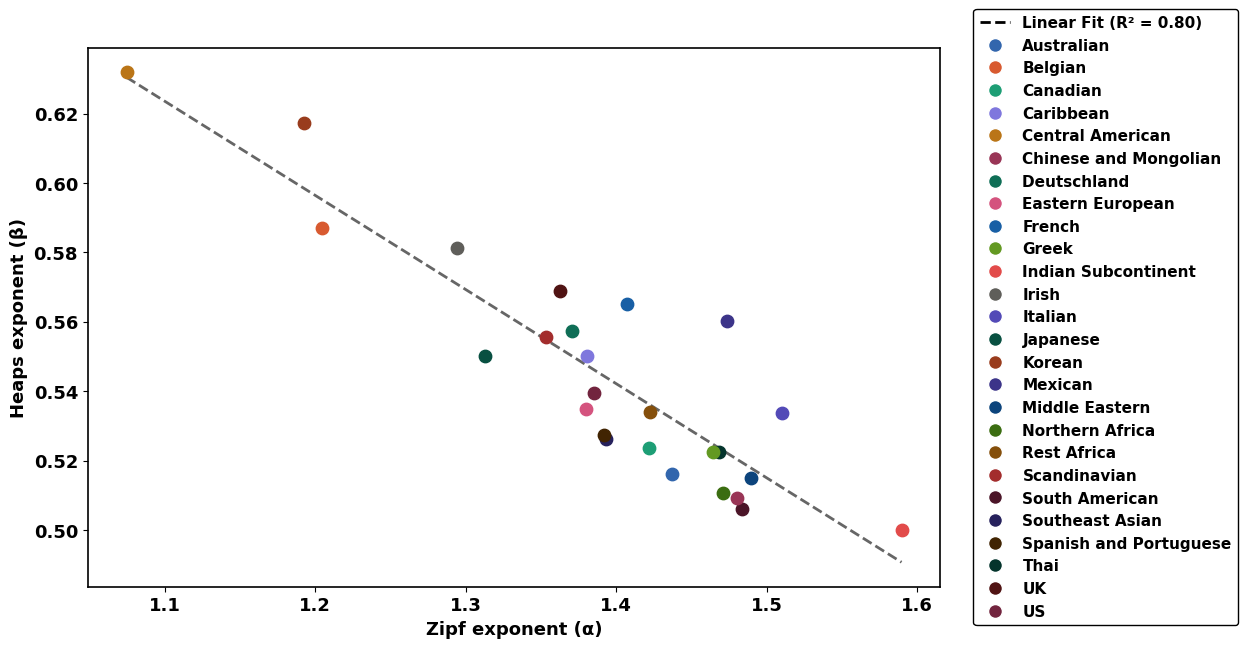


Saved: alpha_vs_beta_linear_fit.png and .tif
Linear Fit Equation: β = -0.2714 * α + 0.9221


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False) # Rule 5: No background grid

    # Rule 6: Plots must be boxed
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

print("Loading data...")
df_zipf = pd.read_csv("zipf_alphas_by_cuisine.csv")
df_heaps = pd.read_csv("heaps_betas_by_cuisine.csv")

# Merge the dataframes on Cuisine
df_merged = pd.merge(df_zipf, df_heaps, on="Cuisine")

# The exact same color palette used in your Menzerath-Altmann script
COLORS = [
    "#3266ad","#D85A30","#1D9E75","#7F77DD","#BA7517","#993556",
    "#0F6E56","#D4537E","#185FA5","#639922","#E24B4A","#5F5E5A",
    "#534AB7","#085041","#993C1D","#3C3489","#0C447C","#3B6D11",
    "#854F0B","#A32D2D","#4B1528","#26215C","#412402","#04342C",
    "#501313","#72243E",
]

# Rule 7: Lock the colors alphabetically to match the MA grid perfectly
all_cuisines_alphabetical = sorted(df_merged["Cuisine"].unique())
cuisine_color_map = {cuisine: COLORS[i % len(COLORS)] for i, cuisine in enumerate(all_cuisines_alphabetical)}

# --- Calculate the Linear Fit (in standard linear scale) ---
x_data = df_merged["Alpha"].values
y_data = df_merged["Beta"].values

slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
r_squared = r_value**2

# Generate x and y values for the line of best fit
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = slope * x_fit + intercept

# Set up the figure - made slightly wider to accommodate the side legend
fig, ax = plt.subplots(figsize=(11, 7))

# Plot the linear regression line (behind the dots)
ax.plot(
    x_fit,
    y_fit,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.6,
    zorder=1
)

# Plot the individual scatter points (NO text annotations inside the plot)
for _, row in df_merged.iterrows():
    name = row["Cuisine"]
    alpha = row["Alpha"]
    beta = row["Beta"]
    col = cuisine_color_map[name]

    ax.scatter(alpha, beta, color=col, s=80, zorder=3)

# Axes labels
ax.set_xlabel("Zipf exponent (α)", fontweight="bold")
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")

# Apply strict axes formatting (No grid, boxed axes)
format_axes(ax)

# --- Create custom boxed legend to the side ---
# Start with the linear fit line and include R-squared
legend_elements = [
    Line2D([0], [0], color="black", linestyle="--", linewidth=2,
           label=f"Linear Fit (R² = {r_squared:.2f})")
]

# Add a colored dot for each cuisine
for cuisine in all_cuisines_alphabetical:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=cuisine,
               markerfacecolor=cuisine_color_map[cuisine], markersize=10)
    )

# Place legend completely outside the main plot box on the right
legend = ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.03, 0.5),
                   frameon=True, fontsize=11, ncol=1)
legend.get_frame().set_edgecolor("black") # Rule 6: Boxed legend

# Rule 1, 2 & 8: Save at 300 DPI.
# bbox_inches="tight" guarantees the side-legend doesn't get cut off.
plt.savefig("alpha_vs_beta_linear_fit.png", dpi=300, bbox_inches="tight")
plt.savefig("alpha_vs_beta_linear_fit.tif", dpi=300, bbox_inches="tight")

plt.show()
print(f"\nSaved: alpha_vs_beta_linear_fit.png and .tif")
print(f"Linear Fit Equation: β = {slope:.4f} * α + {intercept:.4f}")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

print("Preparing Action Data and Generating Alpha/Beta CSVs...")

# 1. Load and prep actions (Read EXCEL instead of CSV)
df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

# 2. Load and prep cuisines (Read EXCEL instead of CSV)
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx")
df_cuisine = df_cuisine.rename(columns={'Region': 'Cuisine'}) # Map Region to Cuisine

# Merge
df_merged = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')
cuisines = [c for c in df_merged['Cuisine'].unique() if pd.notna(c)]

# 3. Zipf Alphas
zipf_results = []
for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    counts = subset['action_id'].value_counts()
    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)
    mask = (ranks >= (10 if len(freqs) > 50 else 0))
    if np.sum(mask) > 5:
        slope, intercept, _, _, std_err = linregress(np.log(ranks[mask]), np.log(freqs[mask]))
        zipf_results.append({'Cuisine': cuisine, 'Alpha': round(-slope, 4)})
pd.DataFrame(zipf_results).to_csv("zipf_alphas_actions_by_cuisine.csv", index=False)

# 4. Heaps Betas
heaps_results = []
for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    recipes = subset.groupby('recipe_no')['action_id'].apply(set).tolist()
    np.random.seed(42)
    shuffled = np.random.permutation(np.array(recipes, dtype=object))
    unique_actions, x_n, y_v, total = set(), [], [], 0
    rate = 10 if len(shuffled) < 1000 else 50
    for i, r in enumerate(shuffled):
        unique_actions.update(r)
        total += len(r)
        if (i + 1) % rate == 0 or (i + 1) == len(shuffled):
            x_n.append(total)
            y_v.append(len(unique_actions))
    if len(x_n) > 5:
        slope, _, _, _, _ = linregress(np.log(np.array(x_n)), np.log(np.array(y_v)))
        heaps_results.append({'Cuisine': cuisine, 'Beta': round(slope, 4)})
pd.DataFrame(heaps_results).to_csv("heaps_betas_actions_by_cuisine.csv", index=False)

print("Action CSVs Generated successfully!")

Preparing Action Data and Generating Alpha/Beta CSVs...
Action CSVs Generated successfully!


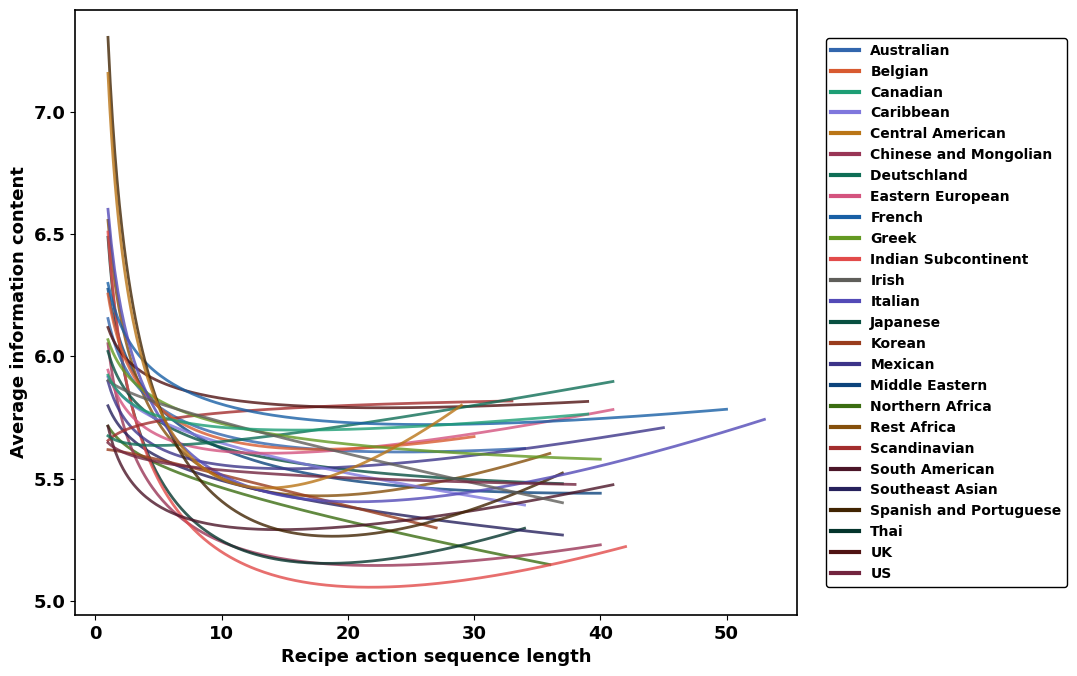

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial"], "font.weight": "bold", "font.size": 13})

def format_axes(ax):
    ax.grid(False) # Rule 5: No grid
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor("black"); spine.set_linewidth(1.2)

# Read EXCEL files
df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx").dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')
cuisines = [c for c in df_merged['Cuisine'].unique() if pd.notna(c)]

# Rule 7: Colors mapped alphabetically
COLORS = ["#3266ad","#D85A30","#1D9E75","#7F77DD","#BA7517","#993556","#0F6E56","#D4537E","#185FA5","#639922","#E24B4A","#5F5E5A","#534AB7","#085041","#993C1D","#3C3489","#0C447C","#3B6D11","#854F0B","#A32D2D","#4B1528","#26215C","#412402","#04342C","#501313","#72243E"]
all_cuisines_alphabetical = sorted(cuisines)
cuisine_color_map = {c: COLORS[i % len(COLORS)] for i, c in enumerate(all_cuisines_alphabetical)}

def ma_model(x, A, b, c): return A * (x**b) * np.exp(-c*x)

# Increased width to 11 to match Cell 3's dimension and make room for the legend
fig, ax = plt.subplots(figsize=(11, 7))
results_ma = []
plotted_cuisines = []

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()
    probs = subset['action_id'].value_counts() / len(subset)
    subset['ic'] = -np.log2(subset['action_id'].map(probs))
    stats = subset.groupby('recipe_no').agg(length=('action_id', 'count'), mean_ic=('ic', 'mean'))
    ma_data = stats.groupby('length')['mean_ic'].mean().reset_index()
    counts = stats['length'].value_counts()
    ma_data = ma_data[ma_data['length'].isin(counts[counts >= 5].index)].sort_values('length')

    if len(ma_data) > 5:
        x_data, y_data = ma_data['length'].values, ma_data['mean_ic'].values
        try:
            popt, _ = curve_fit(ma_model, x_data, y_data, p0=[np.mean(y_data), -0.1, -0.01], maxfev=10000)
            results_ma.append({'Cuisine': cuisine, 'a': popt[0], 'b': popt[1], 'c': popt[2]})
            x_line = np.linspace(min(x_data), max(x_data), 200)
            y_line = ma_model(x_line, *popt)
            col = cuisine_color_map[cuisine]

            ax.plot(x_line, y_line, color=col, alpha=0.8, linewidth=2)
            plotted_cuisines.append(cuisine) # Keep track to only legend what was plotted
            # (Inline text logic has been removed here)

        except: pass

ax.set_xlabel("Recipe action sequence length", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
format_axes(ax)

# --- Create custom boxed legend to the side ---
legend_elements = []
for c in all_cuisines_alphabetical:
    if c in plotted_cuisines:
        # Use a thick line for the legend to match the plot style
        legend_elements.append(Line2D([0], [0], color=cuisine_color_map[c], lw=3, label=c))

legend = ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.03, 0.5), frameon=True, fontsize=10, ncol=1)
legend.get_frame().set_edgecolor("black")

plt.tight_layout()

# bbox_inches="tight" ensures the side legend is perfectly captured in the image
plt.savefig("menzerath_altmann_actions_clean.png", dpi=300, bbox_inches="tight")
plt.savefig("menzerath_altmann_actions_clean.tif", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame(results_ma).to_csv("menzerath_altmann_actions_parameters.csv", index=False)

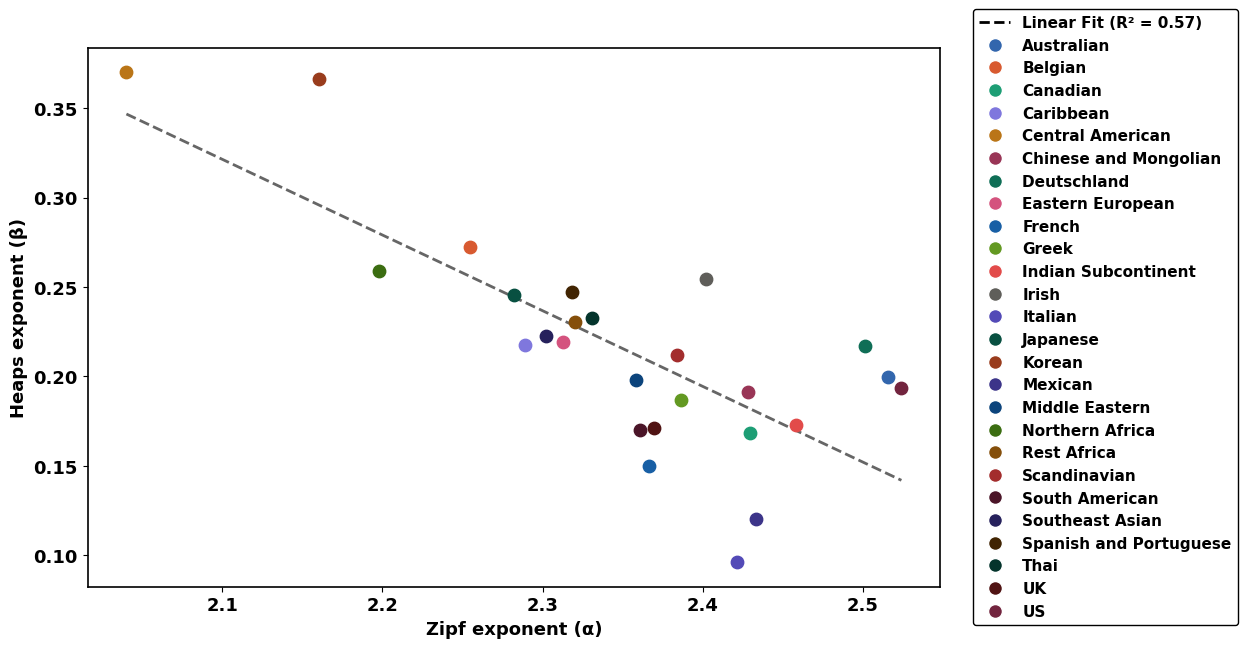

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial"], "font.weight": "bold", "font.size": 13})
def format_axes(ax):
    ax.grid(False)
    for spine in ax.spines.values(): spine.set_visible(True); spine.set_edgecolor("black"); spine.set_linewidth(1.2)

# Reading the new action CSVs created by Cell 1
df_zipf = pd.read_csv("zipf_alphas_actions_by_cuisine.csv")
df_heaps = pd.read_csv("heaps_betas_actions_by_cuisine.csv")
df_merged = pd.merge(df_zipf, df_heaps, on="Cuisine")

COLORS = ["#3266ad","#D85A30","#1D9E75","#7F77DD","#BA7517","#993556","#0F6E56","#D4537E","#185FA5","#639922","#E24B4A","#5F5E5A","#534AB7","#085041","#993C1D","#3C3489","#0C447C","#3B6D11","#854F0B","#A32D2D","#4B1528","#26215C","#412402","#04342C","#501313","#72243E"]
all_cuisines = sorted(df_merged["Cuisine"].unique())
cuisine_color_map = {c: COLORS[i % len(COLORS)] for i, c in enumerate(all_cuisines)}

x_data = df_merged["Alpha"].values
y_data = df_merged["Beta"].values

slope, intercept, r_value, _, _ = linregress(x_data, y_data)
r_squared = r_value**2
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, alpha=0.6, zorder=1)

for _, row in df_merged.iterrows():
    ax.scatter(row["Alpha"], row["Beta"], color=cuisine_color_map[row["Cuisine"]], s=80, zorder=3)

ax.set_xlabel("Zipf exponent (α)", fontweight="bold")
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")
format_axes(ax)

legend_elements = [Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=f"Linear Fit (R² = {r_squared:.2f})")]
for c in all_cuisines:
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=c, markerfacecolor=cuisine_color_map[c], markersize=10))

legend = ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.03, 0.5), frameon=True, fontsize=11, ncol=1)
legend.get_frame().set_edgecolor("black")

plt.savefig("alpha_vs_beta_actions_linear_fit.png", dpi=300, bbox_inches="tight")
plt.savefig("alpha_vs_beta_actions_linear_fit.tif", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ==========================================
# CELL 4: Organize Folders and Download
# ==========================================
import os
import shutil

print("Organizing files into folders...")
# Create nice, clean folders
os.makedirs('Final_Results/Cooking_Techniques_Analysis', exist_ok=True)
os.makedirs('Final_Results/Ingredients_Analysis', exist_ok=True)

# Loop through all files in the Colab environment
for file in os.listdir('.'):
    # Target only our generated plots and CSVs
    if file.endswith(('.png', '.tif', '.csv')):

        # If it has '_actions_' in the name, it goes to the Cooking Techniques folder
        if '_actions_' in file:
            shutil.copy(file, os.path.join('Final_Results/Cooking_Techniques_Analysis', file))

        # For the ingredient files, we grab the plots and the generated CSVs
        # (Filtering out 'RecipeID' to prevent copying your massive raw datasets)
        elif 'RecipeID' not in file:
            shutil.copy(file, os.path.join('Final_Results/Ingredients_Analysis', file))

print("Zipping everything into final_cullinary_results.zip...")
# Zip the structured folder
!cd Final_Results && zip -r -q ../final_cullinary_results.zip *

print("Triggering download...")
# Download to your computer
from google.colab import files
files.download('final_cullinary_results.zip')

Organizing files into folders...
Zipping everything into final_cullinary_results.zip...
Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>